# Laboratorio 1 — Reconocimiento de animales a partir de audio (multi-label)

**Curso:** Deep Learning — Maestría en Data Science & AI, UTEC · **Grupo 2 (Sección 1):** Henry Godino, David Choque, Bryan Montoya

**Paper implementado:** Duan, L., Yang, L., Niu, D., Guo, Y., & Gu, Y. (2026). *Multi-grained detail-enhanced and patch-aware network based on bird sound recognition* (**MEP-Net**). Engineering Applications of Artificial Intelligence, 172, 114274. https://doi.org/10.1016/j.engappai.2026.114274

---

## 0. Cambios respecto a la versión anterior del notebook (v04 → v05)

| # | Problema detectado en v04 | Corrección en v05 | Sección |
|---|---------------------------|-------------------|---------|
| 1 | El split 80/20 era **aleatorio por clip**. Los nombres de archivo (`..._0_3`, `_1_4`, `_2_5`) muestran que los clips son ventanas deslizantes de 3 s con paso de 1 s: clips consecutivos comparten 2 de 3 segundos de audio → **fuga de datos** entre train y validación. | Split **por grabación** (`GroupShuffleSplit` sobre el prefijo estación+fecha+hora). Se cuantifica la fuga que tenía el split anterior. | 4.2, 7 |
| 2 | El umbral de decisión se ajustaba en el **mismo** conjunto usado para early stopping. | El 20 % de validación se divide por grabación en `val_es` (early stopping / selección de modelo) y `val_thr` (ajuste de umbrales). Los umbrales se evalúan en `val_es`, que no los vio. | 7, 8.2 |
| 3 | La ablación comparaba MEP-Net a 60 épocas contra variantes a 30. | **Todas las variantes con el mismo presupuesto** (épocas, semilla, datos, scheduler). Se añade tabla "a igual época". | 9 |
| 4 | mAP excluía clases sin positivos en validación pero F1/precision/recall no (`zero_division=0` deprimía el macro). | Máscara `valid` aplicada a **todas** las métricas; se reporta cuántas clases se evaluaron. | 8 |
| 5 | Un solo umbral global. Todas las confusiones iban hacia SPHSUR (clase dominante). | Umbral **por clase** (solo para clases con ≥10 positivos en `val_thr`; el resto usa el global) y análisis explícito del sesgo hacia la clase dominante. | 8.2, 10 |
| 6 | Normalización min-max por clip (no está en el paper, elimina la intensidad absoluta). | Log-Mel en dB absolutos + **estandarización global** con media/desviación del conjunto de entrenamiento. Se conserva la opción `minmax` para comparar. | 5 |
| 7 | Tres `Conv2d` encadenadas sin no-linealidad en el stem de MDEConv (equivalen a una sola conv lineal). | BN + ReLU entre convoluciones (flag `STEM_NONLINEAR`, documentado como decisión propia). | 6.1 |
| 8 | Sección de análisis sin texto; conclusiones que contradecían la tabla ("clases raras → AP bajo" cuando RHISCI con 1 positivo tenía AP = 1.0). | "Mejores/peores especies" solo entre clases con ≥10 positivos; análisis redactado; resumen automático con los números de la corrida. | 10 |
| 9 | Tres de los cuatro "peores clips" eran espectrogramas casi idénticos (`INCT17_*_57_60`) y no se advirtió. | Detección de **duplicados exactos y casi exactos** en train/val/test por hash del espectrograma. | 4.3 |
| 10 | Una sola semilla; ablaciones adicionales solo como "trabajo futuro". | Semillas extra (opcional), ablación de **θ** (réplica Fig. 9), del cuello de botella 2D→1D y de `pos_weight`, todas con flags y presupuesto de tiempo. | 9.2–9.5 |
| 11 | Sin `requirements.txt` ni tabla de tiempos. | `requirements.txt` adjunto; tabla de tiempos por variante generada automáticamente. | 3, 12 |

---

## 1. Resumen del método (MEP-Net)

MEP-Net reconoce sonidos de aves a partir de **espectrogramas log-Mel** y se compone de tres piezas:

1. **Backbone D-TDNN** (Densely-connected Time Delay Neural Network): capas TDNN (conv1d dilatadas sobre el tiempo) con *conexiones densas* estilo DenseNet — cada capa recibe la concatenación de todas las anteriores — y cuellos de botella FNN (conv1d k=1) que reducen parámetros. Captura dependencias temporales a múltiples contextos y termina en **Statistics Pooling** (media + desviación estándar en el tiempo) que produce un *x-vector* a nivel de clip.
2. **MDEConv** (Multi-grained Detail-enhanced Convolution): fusiona una convolución ordinaria con **cuatro convoluciones diferenciales** — Central (CDC), Angular/diagonal (ADC), Horizontal (HDC) y Vertical (VDC) — que en vez de sumar intensidades ponderan **gradientes locales** `x(p0+pn) − x(p0)` (idea tomada de LBP). Un parámetro θ balancea intensidad vs. gradiente (Eq. 9); el paper encuentra el óptimo en **θ_CDC = θ_ADC = 0.8** (Fig. 9). Esto realza los detalles finos del canto frente al ruido ambiental.
3. **BPAM** (Branch Patch-aware Attention Module): módulo multi-rama con (a) rama **serial** de convoluciones, (b) ramas **patch-aware** con parches de tamaño **p=2 (local)** y **p=4 (global)** que ponderan parches vía MLP + softmax y los filtran por **similitud coseno** con un *embedding* de tarea aprendible (Eq. 10), y (c) atención **CBAM** (canal + espacial). Captura características multi-escala y suprime parches ruidosos.

Resultados del paper: 96.29 % (Birdsdata), 86.51 % (BirdCLEF 2022, acc-47) y 97.40 % (UrbanSound8k).

## 2. Adaptaciones al problema del laboratorio

El paper resuelve clasificación **single-label** (softmax + cross-entropy). Nuestro dataset (grabaciones de la Amazonía, 3 s, 22.05 kHz, mono) es **multi-label a nivel de clip** (0, 1 o varias de 42 especies). Adaptaciones realizadas (todas señaladas también en el código):

| # | Componente | Paper | Nuestra adaptación | Justificación |
|---|-----------|-------|--------------------|---------------|
| 1 | Capa de salida | softmax, 20/47/10 clases | **42 logits + sigmoid** | multi-label: las clases no son mutuamente excluyentes |
| 2 | Pérdida | cross-entropy | **BCEWithLogitsLoss** (variante con `pos_weight` en la ablación 9.5) | pérdida estándar multi-label; estable numéricamente |
| 3 | Métricas | accuracy, precision, recall, F1 (single-label) | **mAP (AP macro), F1 macro/micro, precision/recall macro**, todas sobre las clases con ≥1 positivo en el conjunto evaluado | accuracy simple no es informativa en multi-label |
| 4 | Predicción temporal → clip | Statistics Pooling | se **mantiene** | ya agrega la secuencia temporal en una predicción por grabación |
| 5 | Interfaz 2D→1D (MDEConv/BPAM son 2D, D-TDNN es 1D) | no detallada en el paper | **pooling adaptativo en frecuencia (128→4 bandas) y aplanado canales×bandas como features por frame**; se ablaciona 4 vs 8 vs 16 bandas (9.4) | preserva información tiempo-frecuencia con costo bajo; decisión documentada y medida |
| 6 | Entrada | Mel 128 bandas, FFT 2048 | igual (sr=22050, hop=512, **128×128**), dB absolutos + estandarización global (media/σ de train) | misma representación del paper; sin min-max por clip, que borra la intensidad absoluta |
| 7 | Decisión | argmax | **umbral global y por clase** ajustados en `val_thr` | en multi-label 0.5 rara vez es óptimo; clases raras ⇒ probabilidades bajas |
| 8 | Partición | no aplica | **split por grabación** 80/20 (val dividido en `val_es` / `val_thr`) | los clips son ventanas solapadas de una misma grabación; un split por clip filtra audio de validación a entrenamiento |
| 9 | Épocas | 200 | igual presupuesto para todas las variantes (por defecto 30 + early stopping) | límite de cómputo (GPU 4 GB); la comparación de la ablación debe ser justa |

> **Semilla utilizada: 42** (split por grabación, inicialización y baraje). Semillas adicionales opcionales: 7 y 123.

---
## 3. Configuración e imports

**Instrucciones de ejecución** (Windows + GPU; también corre en Linux/CPU):
```
pip install -r requirements.txt          # o: pip install torch --index-url https://download.pytorch.org/whl/cu121
                                          #     pip install librosa soundfile scikit-learn pandas matplotlib tqdm
```
Editar `DATA_DIR` si el dataset está en otra ruta. El notebook corre completo con *Run All*. Los experimentos opcionales se activan con variables de entorno **antes** de abrir Jupyter (o editando los flags en la celda siguiente).

| Flag | Por defecto | Qué hace | Tiempo aprox. (RTX A2000 4 GB) |
|------|-------------|----------|-------------------------------|
| `RUN_MODE=fast` | `full` | Prueba de humo: 2 épocas, sin extras. Sirve para verificar que todo corre. | ~25 min |
| (núcleo) | siempre | 3 variantes × 30 épocas, misma semilla, split por grabación | ≈ 1.5 h + 2 h + 3 h ≈ **6.5 h** |
| `RUN_EXTRA_SEEDS=1` | 0 | MEP-Net completo con semillas 7 y 123 → media ± σ | +6 h |
| `RUN_THETA_ABLATION=1` | 0 | D-TDNN+MDEConv con θ ∈ {0, 0.5, 1.0} a 12 épocas (0.8 ya está) — réplica Fig. 9 | +2.5 h |
| `RUN_FREQ_ABLATION=1` | 0 | MEP-Net con 8 y 16 bandas de frecuencia a 12 épocas | +2.5 h |
| `RUN_POSWEIGHT_ABLATION=1` | 0 | MEP-Net con `BCEWithLogitsLoss(pos_weight)` a 12 épocas | +1.2 h |

Recomendación con el tiempo disponible: núcleo + `RUN_THETA_ABLATION=1` (es la ablación más alineada con la propuesta central del paper) en una sola noche.

In [1]:
import os, re, math, random, time, hashlib, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             average_precision_score, hamming_loss)
warnings.filterwarnings("ignore")

# ----------------------------- CONFIG -----------------------------
RUN_MODE    = os.getenv("RUN_MODE", "full")        # "full" | "fast" (prueba de humo)
FAST        = RUN_MODE == "fast"

SEED        = 42          # semilla del split por grabación, inicialización y baraje
SR          = 22050       # frecuencia de muestreo del dataset
N_FFT       = 2048        # FFT como en el paper (Sección 2.3)
HOP         = 512
N_MELS      = 128         # 128 filtros Mel como en el paper
N_FRAMES    = 128         # ~3 s -> recortamos/rellenamos a 128 frames
N_CLASSES   = 42
BATCH_SIZE  = 32          # batch 32 como en el paper (Sección 4.1)
LR          = 1e-4        # Adam lr=1e-4 como en el paper
EPOCHS      = 2 if FAST else 30   # MISMO presupuesto para las 3 variantes (paper: 200)
EXTRA_EPOCHS= 2 if FAST else 12   # épocas para las ablaciones adicionales (theta, bandas, pos_weight)
PATIENCE    = 10          # early stopping sobre mAP de val_es
NORM        = "global"    # "global" (estandarización con media/σ de train) | "minmax" (comportamiento v04)
STEM_NONLINEAR = True     # BN+ReLU entre las 3 conv del stem de MDEConv (decisión propia, ver 6.1)
FREQ_BINS   = 4           # bandas de frecuencia tras el pooling 2D->1D (se ablaciona en 9.4)
MIN_POS_CLASE = 10        # mínimo de positivos para (a) umbral por clase y (b) rankings por especie
TH_GRID     = np.round(np.arange(0.05, 0.95, 0.01), 2)

RUN_EXTRA_SEEDS        = os.getenv("RUN_EXTRA_SEEDS", "0") == "1" and not FAST
RUN_THETA_ABLATION     = os.getenv("RUN_THETA_ABLATION", "0") == "1" and not FAST
RUN_FREQ_ABLATION      = os.getenv("RUN_FREQ_ABLATION", "0") == "1" and not FAST
RUN_POSWEIGHT_ABLATION = os.getenv("RUN_POSWEIGHT_ABLATION", "0") == "1" and not FAST
SEEDS_EXTRA = [7, 123]

# Rutas candidatas al dataset (editar si es necesario)
_CANDIDATES = [
    Path(r"C:\Users\hgodino.INACONS\Desktop\UTEC MAESTRIA\Ciclo5\Deep Learning\Laboratorios\Laboratorio 1\data"),
    Path("./data"), Path("../data"), Path("./data_synth"),
]
DATA_DIR = next((p for p in _CANDIDATES if (p / "train.csv").exists()), _CANDIDATES[0])
TRAIN_DIR, TEST_DIR, TRAIN_CSV = DATA_DIR / "train", DATA_DIR / "test", DATA_DIR / "train.csv"
CKPT_DIR  = Path("./checkpoints"); CKPT_DIR.mkdir(exist_ok=True)
CACHE_DIR = Path("./mel_cache_v2"); CACHE_DIR.mkdir(exist_ok=True)   # v2: dB absolutos, sin min-max
OUT_DIR   = Path("./salidas"); OUT_DIR.mkdir(exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)
set_seed()

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

TIMES = {}   # nombre de experimento -> segundos de entrenamiento (tabla en la Sección 12)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Modo   : {RUN_MODE}  | épocas núcleo={EPOCHS} | extras={EXTRA_EPOCHS}")
print(f"Extras : seeds={RUN_EXTRA_SEEDS} theta={RUN_THETA_ABLATION} bandas={RUN_FREQ_ABLATION} pos_weight={RUN_POSWEIGHT_ABLATION}")
print(f"Dataset: {DATA_DIR.resolve()}")
print(f"Device : {DEVICE}", torch.cuda.get_device_name(0) if DEVICE.type == "cuda" else "")

Modo   : full  | épocas núcleo=30 | extras=12
Extras : seeds=False theta=False bandas=False pos_weight=False
Dataset: D:\UTEC MAESTRIA\Ciclo5\Deep Learning\Laboratorios\Laboratorio 1\data
Device : cuda NVIDIA RTX A2000 Laptop GPU


---
## 4. Carga y exploración de los datos

### 4.1 Etiquetas
`train.csv`: la primera columna es el nombre del archivo y las 42 restantes indican presencia/ausencia (0/1) de cada especie.

In [2]:
df = pd.read_csv(TRAIN_CSV)
FILE_COL = df.columns[0]
CLASS_NAMES = list(df.columns[1:])
assert len(CLASS_NAMES) == N_CLASSES, f"Se esperaban 42 clases, hay {len(CLASS_NAMES)}"
labels_mat = df[CLASS_NAMES].values.astype(np.float32)
test_files = sorted(TEST_DIR.glob("*.wav"))

n_por_clip = labels_mat.sum(axis=1)
counts = labels_mat.sum(axis=0)
print(f"Grabaciones (clips) de entrenamiento : {len(df)}")
print(f"Archivos de test                     : {len(test_files)}")
print(f"Etiquetas por clip -> media {n_por_clip.mean():.2f} | min {int(n_por_clip.min())} | max {int(n_por_clip.max())}")
print(f"Clips sin ninguna especie            : {(n_por_clip==0).sum()} ({100*(n_por_clip==0).mean():.1f}%)")
print("Clases con <10 clips positivos       :", [f"{CLASS_NAMES[i]} ({int(counts[i])})" for i in range(N_CLASSES) if counts[i] < 10])
CLASE_DOMINANTE = CLASS_NAMES[int(np.argmax(counts))]
print(f"Clase dominante                      : {CLASE_DOMINANTE} ({100*counts.max()/len(df):.1f}% de los clips)")
df.head()

Grabaciones (clips) de entrenamiento : 62191
Archivos de test                     : 31187
Etiquetas por clip -> media 1.51 | min 0 | max 8
Clips sin ninguna especie            : 22504 (36.2%)
Clases con <10 clips positivos       : ['SCIFUS (0)', 'SCINAS (0)', 'LEPFLA (7)']
Clase dominante                      : SPHSUR (21.3% de los clips)


,filename,SPHSUR,BOABIS,SCIPER,DENNAH,LEPLAT,RHIICT,BOALEP,BOAFAB,PHYCUV,...,SCINAS,LEPNOT,ADEMAR,BOAALM,PHYDIS,RHIORN,LEPFLA,SCIRIZ,DENELE,SCIALT
0,INCT20955_20190909_050000_0_3.wav,0,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,INCT20955_20190909_050000_1_4.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,INCT20955_20190909_050000_2_5.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,INCT20955_20190909_050000_3_6.wav,1,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,INCT20955_20190909_050000_4_7.wav,1,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


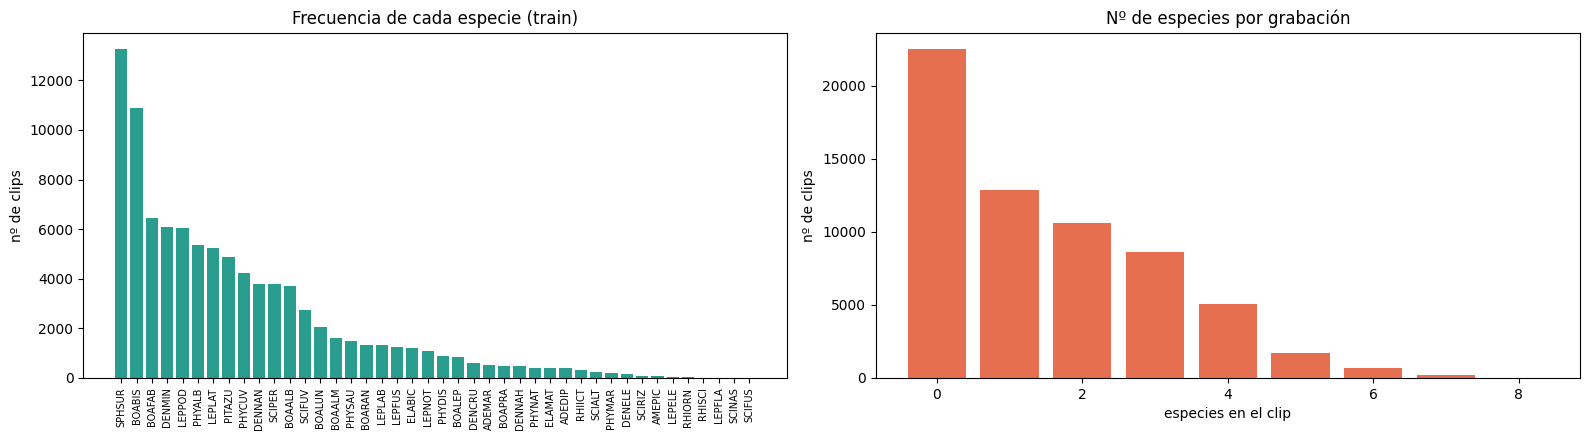

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))
order = np.argsort(counts)[::-1]
axes[0].bar(range(N_CLASSES), counts[order], color="#2a9d8f")
axes[0].set_xticks(range(N_CLASSES))
axes[0].set_xticklabels([CLASS_NAMES[i] for i in order], rotation=90, fontsize=7)
axes[0].set_title("Frecuencia de cada especie (train)"); axes[0].set_ylabel("nº de clips")
vals, cnts = np.unique(n_por_clip.astype(int), return_counts=True)
axes[1].bar(vals, cnts, color="#e76f51")
axes[1].set_title("Nº de especies por grabación"); axes[1].set_xlabel("especies en el clip"); axes[1].set_ylabel("nº de clips")
plt.tight_layout(); plt.show()

### 4.2 Estructura de los archivos: los clips son ventanas solapadas de una misma grabación

El nombre `INCT20955_20190909_050000_0_3.wav` codifica `estación_fecha_hora_inicio_fin` (segundos dentro de la grabación). Los clips `_0_3`, `_1_4`, `_2_5`… son ventanas de 3 s con **paso de 1 s**: dos clips consecutivos comparten 2 s de audio. Si el split 80/20 se hace por clip, casi todo clip de validación tiene un "vecino" en entrenamiento con el que comparte el 67 % del audio (y normalmente las mismas etiquetas). Eso es fuga de datos y produce métricas de validación optimistas. Aquí lo verificamos y lo cuantificamos antes de construir el split correcto.

In [4]:
_pat = re.compile(r"^(?P<rec>.+)_(?P<ini>\d+)_(?P<fin>\d+)\.wav$")
def parse_name(fn):
    m = _pat.match(str(fn))
    if m is None:
        return None, np.nan, np.nan
    return m.group("rec"), int(m.group("ini")), int(m.group("fin"))

parsed = [parse_name(f) for f in df[FILE_COL]]
df["rec_id"] = [p[0] if p[0] is not None else Path(f).stem for p, f in zip(parsed, df[FILE_COL])]
df["t_ini"]  = [p[1] for p in parsed]
df["t_fin"]  = [p[2] for p in parsed]
ok = df["t_ini"].notna().mean()
print(f"Nombres con patrón estación_fecha_hora_ini_fin: {100*ok:.1f}%")
print(f"Grabaciones distintas (rec_id): {df['rec_id'].nunique()}  |  clips por grabación: "
      f"media {df.groupby('rec_id').size().mean():.1f}, máx {df.groupby('rec_id').size().max()}")
dur = (df["t_fin"] - df["t_ini"]).dropna()
print(f"Duración de la ventana (fin-ini): {dur.value_counts().to_dict()}")

# paso entre clips consecutivos de una misma grabación
steps = (df.sort_values(["rec_id", "t_ini"]).groupby("rec_id")["t_ini"].diff().dropna())
print(f"Paso entre ventanas consecutivas (s): {steps.value_counts().head(5).to_dict()}")

# Ejemplo: una grabación con varios clips y sus etiquetas
ej = df[df["rec_id"] == df["rec_id"].iloc[0]].sort_values("t_ini").head(6)
print("\nEjemplo de clips consecutivos de la misma grabación y sus especies:")
for _, r in ej.iterrows():
    print(f"  {r[FILE_COL]:45s} -> {[c for c in CLASS_NAMES if r[c] == 1]}")

# ---- Cuantificación de la fuga del split ALEATORIO POR CLIP (el de la versión anterior) ----
rng = np.random.RandomState(SEED)
perm = rng.permutation(len(df)); n_val_old = int(round(0.2 * len(df)))
val_old, tr_old = set(perm[:n_val_old]), set(perm[n_val_old:])
by_rec = df.groupby("rec_id").indices
leaked = 0
for i in val_old:
    rec, t0 = df["rec_id"].iat[i], df["t_ini"].iat[i]
    for j in by_rec[rec]:
        if j in tr_old and abs(df["t_ini"].iat[j] - t0) < 3:
            leaked += 1; break
print(f"\nSplit aleatorio por clip (v04): {100*leaked/n_val_old:.1f}% de los clips de validación "
      f"comparten audio (>0 s de solape) con algún clip de entrenamiento.")
print("=> Con ese split, validación no mide generalización a grabaciones nuevas. Sección 7 corrige esto.")

Nombres con patrón estación_fecha_hora_ini_fin: 100.0%
Grabaciones distintas (rec_id): 1074  |  clips por grabación: media 57.9, máx 58
Duración de la ventana (fin-ini): {3: 62191}
Paso entre ventanas consecutivas (s): {1.0: 61117}

Ejemplo de clips consecutivos de la misma grabación y sus especies:
  INCT20955_20190909_050000_0_3.wav             -> ['SCIPER']
  INCT20955_20190909_050000_1_4.wav             -> ['SPHSUR', 'BOABIS', 'SCIPER']
  INCT20955_20190909_050000_2_5.wav             -> ['SPHSUR', 'BOABIS', 'SCIPER']
  INCT20955_20190909_050000_3_6.wav             -> ['SPHSUR', 'BOABIS', 'SCIPER']
  INCT20955_20190909_050000_4_7.wav             -> ['SPHSUR', 'SCIPER']
  INCT20955_20190909_050000_5_8.wav             -> ['SPHSUR', 'SCIPER']

Split aleatorio por clip (v04): 99.7% de los clips de validación comparten audio (>0 s de solape) con algún clip de entrenamiento.
=> Con ese split, validación no mide generalización a grabaciones nuevas. Sección 7 corrige esto.


In [5]:
# ¿Comparte el test grabaciones con train? (si lo hiciera, la evaluación oficial también tendría fuga)
test_recs = pd.Series([parse_name(p.name)[0] or p.stem for p in test_files])
inter = set(test_recs) & set(df["rec_id"])
print(f"Grabaciones en test: {test_recs.nunique()} | compartidas con train: {len(inter)}")
if inter:
    print("  Ejemplos:", list(inter)[:5])
    print("  -> El test SÍ comparte grabaciones con train: las métricas oficiales pueden ser optimistas;"
          " nuestra validación por grabación es más exigente que el test.")
else:
    print("  -> Test y train NO comparten grabaciones: el split por grabación replica la situación real del test.")

Grabaciones en test: 538 | compartidas con train: 0
  -> Test y train NO comparten grabaciones: el split por grabación replica la situación real del test.


---
## 5. Representación: espectrograma log-Mel (Sección 2.3 del paper)

Pipeline del paper: pre-énfasis → framing → ventana → FFT (2048) → banco de **128 filtros Mel** → log (Eq. 4). Precalculamos todos los espectrogramas una sola vez y los guardamos en caché (`.npy`).

**Cambio respecto a v04:** guardamos los dB **absolutos** (`ref=1.0`, sin `top_db`). La normalización se hace después con la media y desviación del conjunto de **entrenamiento** (`NORM="global"`), no con min-max por clip: el min-max borra la intensidad absoluta (un clip de puro ruido de fondo queda igual de "brillante" que un canto fuerte) y no forma parte del paper. `NORM="minmax"` reproduce el comportamiento anterior para comparar.

In [6]:
def wav_to_logmel(path, pre_emphasis=0.97):
    y, _ = librosa.load(path, sr=SR, mono=True)
    y = np.append(y[0], y[1:] - pre_emphasis * y[:-1])          # (1) pre-énfasis
    mel = librosa.feature.melspectrogram(                        # (2)-(4) framing+ventana+FFT+Mel
        y=y, sr=SR, n_fft=N_FFT, hop_length=HOP, n_mels=N_MELS, power=2.0)
    logmel = librosa.power_to_db(mel, ref=1.0, top_db=None).astype(np.float32)   # Eq. (4): log, dB absolutos
    T = logmel.shape[1]
    if T < N_FRAMES:
        logmel = np.pad(logmel, ((0, 0), (0, N_FRAMES - T)), constant_values=logmel.min())
    else:
        logmel = logmel[:, :N_FRAMES]
    return logmel                                                # (128, 128), sin normalizar

def get_mel_cached(wav_path, split):
    cache = CACHE_DIR / split / (Path(wav_path).stem + ".npy")
    if cache.exists():
        return np.load(cache)
    cache.parent.mkdir(parents=True, exist_ok=True)
    m = wav_to_logmel(wav_path)
    np.save(cache, m)
    return m

from tqdm.auto import tqdm
t0 = time.time()
for fn in tqdm(df[FILE_COL], desc="cache train"):
    get_mel_cached(TRAIN_DIR / fn, "train")
for p in tqdm(test_files, desc="cache test"):
    get_mel_cached(p, "test")
print(f"Espectrogramas cacheados en {time.time()-t0:.1f}s -> {CACHE_DIR.resolve()}")

cache test: 100%|██████████| 31187/31187 [04:54<00:00, 105.92it/s]

Espectrogramas cacheados en 863.1s -> D:\UTEC MAESTRIA\Ciclo5\Deep Learning\Laboratorios\Laboratorio 1\mel_cache_v2


### 4.3 (cont.) Duplicados exactos y casi exactos

En v04 tres de los cuatro clips con mayor error eran espectrogramas visualmente idénticos con fechas distintas (`INCT17_*_57_60`). Comprobamos si el dataset contiene clips duplicados (hash del espectrograma) y si esos duplicados cruzan train/val/test.

In [7]:
def mel_hash(m):
    return hashlib.md5(np.round(m, 2).tobytes()).hexdigest()

hashes = {}
for fn in tqdm(df[FILE_COL], desc="hash train"):
    hashes.setdefault(mel_hash(get_mel_cached(TRAIN_DIR / fn, "train")), []).append(("train", fn))
for p in tqdm(test_files, desc="hash test"):
    hashes.setdefault(mel_hash(get_mel_cached(p, "test")), []).append(("test", p.name))

dup_groups = [v for v in hashes.values() if len(v) > 1]
n_dup_clips = sum(len(v) for v in dup_groups)
cross_tt = [v for v in dup_groups if {s for s, _ in v} == {"train", "test"}]
print(f"Grupos de duplicados exactos: {len(dup_groups)} ({n_dup_clips} clips) | grupos que cruzan train↔test: {len(cross_tt)}")
for v in dup_groups[:5]:
    print("  ", [f for _, f in v][:4], "..." if len(v) > 4 else "")

# clips que terminan en _57_60 (último tramo de cada grabación): ¿son anómalos?
end_clips = df[df["t_ini"] == df.groupby("rec_id")["t_ini"].transform("max")]
print(f"\nClips que son el último tramo de su grabación: {len(end_clips)} "
      f"({100*len(end_clips)/len(df):.1f}%) | con al menos una especie: {100*(end_clips[CLASS_NAMES].sum(axis=1)>0).mean():.1f}% "
      f"(global: {100*(n_por_clip>0).mean():.1f}%)")

# similitud (correlación) entre los tres clips señalados en v04, si existen
flag = [f for f in ["INCT17_20201116_203000_57_60.wav", "INCT17_20191222_211500_57_60.wav", "INCT17_20191217_010000_57_60.wav"]
        if (TRAIN_DIR / f).exists()]
if len(flag) >= 2:
    mats = [get_mel_cached(TRAIN_DIR / f, "train").ravel() for f in flag]
    print("\nCorrelación entre los clips señalados en v04:")
    for a in range(len(flag)):
        for b in range(a + 1, len(flag)):
            print(f"  {flag[a]} vs {flag[b]}: r = {np.corrcoef(mats[a], mats[b])[0,1]:.4f}")
    print("  (r > 0.99 con fechas distintas sugiere audio duplicado o un artefacto del corte final del archivo)")

hash test: 100%|██████████| 31187/31187 [00:42<00:00, 727.44it/s] 

Grupos de duplicados exactos: 1 (1528 clips) | grupos que cruzan train↔test: 1
   ['INCT20955_20190909_050000_57_60.wav', 'INCT20955_20190909_171500_57_60.wav', 'INCT20955_20190911_004500_57_60.wav', 'INCT20955_20190911_024500_57_60.wav'] ...

Clips que son el último tramo de su grabación: 1074 (1.7%) | con al menos una especie: 63.1% (global: 63.8%)

Correlación entre los clips señalados en v04:
  INCT17_20201116_203000_57_60.wav vs INCT17_20191222_211500_57_60.wav: r = 1.0000
  INCT17_20201116_203000_57_60.wav vs INCT17_20191217_010000_57_60.wav: r = 1.0000
  INCT17_20191222_211500_57_60.wav vs INCT17_20191217_010000_57_60.wav: r = 1.0000
  (r > 0.99 con fechas distintas sugiere audio duplicado o un artefacto del corte final del archivo)


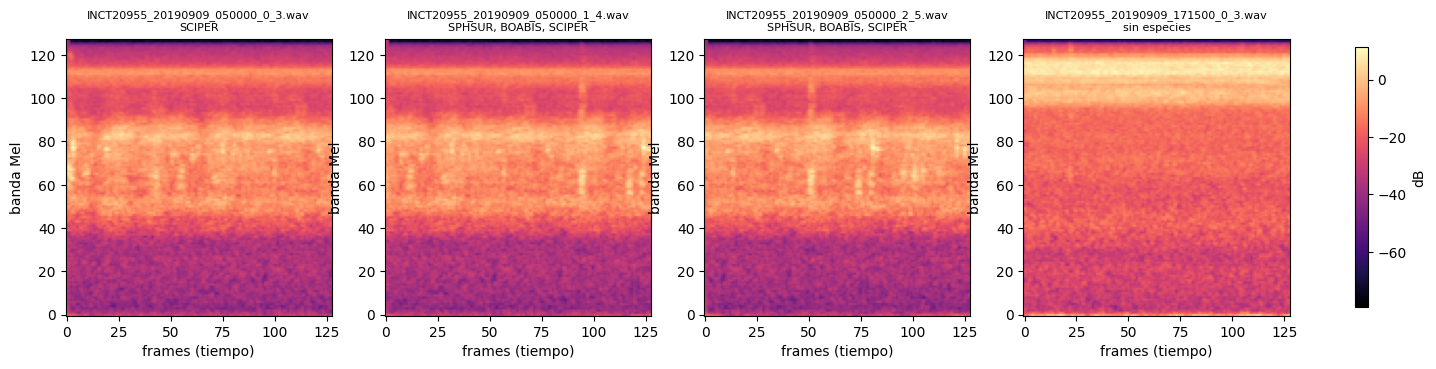

In [8]:
# Visualización de ejemplos
idx_multi = np.where(n_por_clip >= 2)[0][:2] if (n_por_clip >= 2).any() else [0, 1]
idx_none  = np.where(n_por_clip == 0)[0][:1]
idx_one   = np.where(n_por_clip == 1)[0][:1]
show = list(idx_one) + list(idx_multi) + list(idx_none)
fig, axes = plt.subplots(1, len(show), figsize=(4.2*len(show), 3.6))
for ax, i in zip(np.atleast_1d(axes), show):
    m = get_mel_cached(TRAIN_DIR / df[FILE_COL].iloc[i], "train")
    im = ax.imshow(m, aspect="auto", origin="lower", cmap="magma")
    present = [CLASS_NAMES[j] for j in range(N_CLASSES) if labels_mat[i, j] == 1]
    ax.set_title(f"{df[FILE_COL].iloc[i]}\n{', '.join(present) if present else 'sin especies'}", fontsize=8)
    ax.set_xlabel("frames (tiempo)"); ax.set_ylabel("banda Mel")
plt.colorbar(im, ax=list(np.atleast_1d(axes)), fraction=0.01, label="dB")
plt.show()

---
## 6. Implementación de MEP-Net

### 6.1 Convoluciones diferenciales y MDEConv (Sección 3.1, Fig. 4)

La convolución diferencial (Eq. 8–9) pondera **gradientes** respecto al píxel central en lugar de intensidades:

$$y(p_0)=\theta\sum_{p_n\in R}\omega(p_n)\,(x(p_0{+}p_n)-x(p_0)) + (1-\theta)\sum_{p_n\in R}\omega(p_n)\,x(p_0{+}p_n)$$

Desarrollando: $y = \sum_R \omega\, x(p_0{+}p_n) - \theta\, x(p_0)\sum_R \omega$, es decir **`conv(x) − θ·x·Σω`**, donde el segundo término es una convolución 1×1 cuyo kernel es la suma del kernel 3×3 (por canal de entrada/salida). El vecindario $R$ se restringe con **máscaras binarias 3×3**: CDC (todo), ADC (diagonales), HDC (horizontal = tiempo), VDC (vertical = frecuencia). Usamos **θ_CDC = θ_ADC = 0.8** (óptimo de la Fig. 9, que replicamos en 9.3) y θ=1 para HDC/VDC (patrón direccional fijo).

**Decisión propia (flag `STEM_NONLINEAR`):** en v04 el stem tenía tres `Conv2d` 3×3 consecutivas sin activación; tres convoluciones lineales encadenadas equivalen a una sola convolución lineal 7×7, así que no aportaban capacidad. Insertamos BN+ReLU entre ellas. Si el paper describe explícitamente el stem sin activaciones, basta poner `STEM_NONLINEAR=False`.

In [9]:
class DiffConv2d(nn.Module):
    """Convolución diferencial genérica con máscara direccional y theta adaptable."""

    MASKS = {
        "cdc": [[1, 1, 1], [1, 1, 1], [1, 1, 1]],           # central (todo)
        "adc": [[1, 0, 1], [0, 1, 0], [1, 0, 1]],           # angular (diagonales)
        "hdc": [[0, 0, 0], [1, 1, 1], [0, 0, 0]],           # horizontal (eje tiempo)
        "vdc": [[0, 1, 0], [0, 1, 0], [0, 1, 0]],           # vertical (eje frecuencia)
    }

    def __init__(self, in_ch, out_ch, kind="cdc", theta=0.8):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.theta = float(theta)
        mask = torch.tensor(self.MASKS[kind], dtype=torch.float32)
        self.register_buffer("mask", mask.view(1, 1, 3, 3))

    def forward(self, x):
        w = self.conv.weight * self.mask          # restringe el kernel al vecindario R
        y = F.conv2d(x, w, padding=1)             # sum_R w * x(p0+pn)
        if self.theta > 0:
            w_sum = w.sum(dim=(2, 3), keepdim=True)   # (out,in,1,1): conv 1x1 con la suma del kernel
            y = y - self.theta * F.conv2d(x, w_sum)   # - theta * x(p0) * sum(w)
        return y


class DEConv(nn.Module):
    """Fusión: conv ordinaria + CDC + ADC + HDC + VDC en paralelo (Fig. 4)."""

    def __init__(self, ch, theta_cdc=0.8, theta_adc=0.8, use_diff=True):
        super().__init__()
        self.vanilla = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.use_diff = use_diff
        if use_diff:
            self.cdc = DiffConv2d(ch, ch, "cdc", theta=theta_cdc)
            self.adc = DiffConv2d(ch, ch, "adc", theta=theta_adc)
            self.hdc = DiffConv2d(ch, ch, "hdc", theta=1.0)
            self.vdc = DiffConv2d(ch, ch, "vdc", theta=1.0)

    def forward(self, x):
        y = self.vanilla(x)
        if self.use_diff:
            y = y + self.cdc(x) + self.adc(x) + self.hdc(x) + self.vdc(x)
        return y


class MDEConv(nn.Module):
    """MDEConv (Fig. 4): stem conv2d(k3)+BN+ReLU -> 3x conv2d(k3) -> BN+ReLU -> DEConv."""

    def __init__(self, in_ch=1, ch=32, use_diff=True, theta=0.8, stem_nonlinear=STEM_NONLINEAR):
        super().__init__()
        def act(): return [nn.BatchNorm2d(ch), nn.ReLU(inplace=True)] if stem_nonlinear else []
        layers = [nn.Conv2d(in_ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True)]
        layers += [nn.Conv2d(ch, ch, 3, padding=1, bias=False), *act(),
                   nn.Conv2d(ch, ch, 3, padding=1, bias=False), *act(),
                   nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.BatchNorm2d(ch), nn.ReLU(inplace=True)]
        self.stem = nn.Sequential(*layers)
        self.deconv = DEConv(ch, theta_cdc=theta, theta_adc=theta, use_diff=use_diff)
        self.bn_out = nn.BatchNorm2d(ch)

    def forward(self, x):
        return F.relu(self.bn_out(self.deconv(self.stem(x))))

### 6.2 BPAM (Sección 3.2, Fig. 6)

Tres ramas en paralelo: **serial** (convoluciones 3×3 encadenadas), **patch local (p=2)** y **patch global (p=4)**. Cada rama patch-aware: partición en parches → mean-pool de canal → proyección a C ("mapped to channel number C", Sec. 3.2) → MLP + softmax espacial (pesos por parche) → **selección por similitud coseno** con un embedding de tarea aprendible ξ (Eq. 10: $\hat t_i = P\cdot sim(t_i,\xi)\cdot t_i$) → upsample bilinear → conv 1×1. La fusión pasa por **CBAM** (atención de canal + espacial), dropout, BN y ReLU.

> Nota de fidelidad: el promedio sobre canales antes de la proyección sigue la descripción textual del paper ("cada parche se promedia y se mapea a C canales"). Es la interpretación más literal que encontramos; si el paper conserva los canales, la alternativa sería una proyección lineal de $p^2\cdot C \to C$.

In [10]:
class PatchAware(nn.Module):
    """Rama patch-aware: divide el mapa en parches p x p, pondera cada parche
    con un MLP + softmax espacial y selecciona características por similitud
    coseno con un embedding de tarea aprendible (Eq. 10)."""

    def __init__(self, ch, p):
        super().__init__()
        self.p = p
        self.to_channel = nn.Linear(p * p, ch)      # p*p -> C ("mapped to channel number C")
        self.mlp = nn.Sequential(nn.Linear(ch, ch), nn.ReLU(inplace=True), nn.Linear(ch, ch))
        self.task_embed = nn.Parameter(torch.randn(ch) * 0.02)  # xi (embedding de tarea)
        self.proj = nn.Linear(ch, ch, bias=False)                # P (Eq. 10)
        self.out_conv = nn.Conv2d(ch, ch, 1, bias=False)

    def forward(self, x):
        B, C, H, W = x.shape
        p = self.p
        Hp, Wp = H // p, W // p
        t = x.view(B, C, Hp, p, Wp, p).permute(0, 2, 4, 3, 5, 1).reshape(B, Hp * Wp, p * p, C)
        t = self.to_channel(t.mean(dim=3))           # (B, N, C)
        w = F.softmax(self.mlp(t), dim=1)            # pesos espaciales (softmax sobre N)
        t = w * t                                    # parches ponderados t_i
        sim = F.cosine_similarity(t, self.task_embed.view(1, 1, -1), dim=-1)  # (B, N)
        h = self.proj(t) * sim.unsqueeze(-1)         # h_i = P * sim(t_i, xi) * t_i
        h = h.permute(0, 2, 1).reshape(B, C, Hp, Wp)
        h = F.interpolate(h, size=(H, W), mode="bilinear", align_corners=False)
        return self.out_conv(h)


class ChannelAttention(nn.Module):
    def __init__(self, ch, r=8):
        super().__init__()
        self.mlp = nn.Sequential(nn.Linear(ch, ch // r), nn.ReLU(inplace=True), nn.Linear(ch // r, ch))

    def forward(self, x):
        avg = self.mlp(x.mean(dim=(2, 3)))
        mx = self.mlp(x.amax(dim=(2, 3)))
        return x * torch.sigmoid(avg + mx).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, k, padding=k // 2, bias=False)

    def forward(self, x):
        s = torch.cat([x.mean(dim=1, keepdim=True), x.amax(dim=1, keepdim=True)], dim=1)
        return x * torch.sigmoid(self.conv(s))


class BPAM(nn.Module):
    """BPAM (Fig. 6): rama serial + ramas patch-aware (p=2, p=4) + CBAM."""

    def __init__(self, ch, p_local=2, p_global=4, dropout=0.1):
        super().__init__()
        self.conv_a = nn.Conv2d(ch, ch, 3, padding=1, bias=False)
        self.conv_b = nn.Sequential(nn.Conv2d(ch, ch, 3, padding=1, bias=False), nn.ReLU(inplace=True),
                                    nn.Conv2d(ch, ch, 3, padding=1, bias=False))
        self.conv1x1 = nn.Conv2d(ch, ch, 1, bias=False)
        self.patch_local = PatchAware(ch, p_local)    # p=2: detalles locales
        self.patch_global = PatchAware(ch, p_global)  # p=4: contexto global
        self.cbam_c = ChannelAttention(ch)
        self.cbam_s = SpatialAttention()
        self.dropout = nn.Dropout2d(dropout)
        self.bn = nn.BatchNorm2d(ch)

    def forward(self, x):
        a = self.conv_a(x)
        serial = a + self.conv_b(a)                            # rama serial
        z = self.conv1x1(x)
        patches = self.patch_local(z) + self.patch_global(z)  # ramas de parches
        y = self.cbam_s(self.cbam_c(serial + patches))        # fusión + CBAM
        return F.relu(self.bn(self.dropout(y)))

### 6.3 Backbone D-TDNN y modelo completo (Fig. 1, 7)

Cada capa D-TDNN: FNN cuello de botella (conv1d k=1 → 2g) + capa TDNN (conv1d k=3 dilatada → g=64) con **conexión densa** ($d^l = D^l([d^0,\dots,d^{l-1}])$, Eq. 1). Estructura: stem → **6 bloques** → transición → **12 bloques** → Statistics Pooling → FC → cabeza de **42 logits** (adaptación #1). Las dilataciones ciclan 1-2-3 dentro de cada bloque para ampliar el contexto temporal (D-TDNN original de Yu & Li, 2020, usa dilataciones crecientes; el paper no las lista, así que es una decisión propia declarada).

Los flags `use_mdeconv` / `use_bpam` construyen las variantes de la **ablación** (Tabla 4 del paper); `theta` y `freq_bins_out` permiten las ablaciones adicionales (9.3, 9.4).

In [11]:
class DTDNNLayer(nn.Module):
    def __init__(self, in_ch, growth=64, dilation=1):
        super().__init__()
        bottleneck = 2 * growth
        self.fnn = nn.Sequential(nn.BatchNorm1d(in_ch), nn.ReLU(inplace=True),
                                 nn.Conv1d(in_ch, bottleneck, 1, bias=False))
        self.tdnn = nn.Sequential(nn.BatchNorm1d(bottleneck), nn.ReLU(inplace=True),
                                  nn.Conv1d(bottleneck, growth, 3, padding=dilation, dilation=dilation, bias=False))

    def forward(self, x):
        return torch.cat([x, self.tdnn(self.fnn(x))], dim=1)  # d^l = D([d^0..d^{l-1}])


class DTDNNBlock(nn.Module):
    def __init__(self, in_ch, n_layers, growth=64):
        super().__init__()
        layers, ch = [], in_ch
        for i in range(n_layers):
            layers.append(DTDNNLayer(ch, growth, dilation=(i % 3) + 1))
            ch += growth
        self.block = nn.Sequential(*layers)
        self.out_ch = ch

    def forward(self, x):
        return self.block(x)


class StatsPooling(nn.Module):
    """media + desviación estándar sobre el tiempo -> x-vector a nivel de clip
    (convierte la secuencia temporal en UNA predicción por grabación)."""
    def forward(self, x):
        return torch.cat([x.mean(dim=2), x.std(dim=2)], dim=1)


class MEPNet(nn.Module):
    """use_mdeconv / use_bpam -> variantes de la ablación (Tabla 4 del paper)."""

    def __init__(self, n_classes=42, n_mels=128, ch2d=32, growth=64, blocks=(6, 12), emb_dim=256,
                 freq_bins_out=FREQ_BINS, use_mdeconv=True, use_bpam=True, use_diff=True, theta=0.8):
        super().__init__()
        self.use_bpam = use_bpam
        if use_mdeconv:
            self.mdeconv = MDEConv(1, ch2d, use_diff=use_diff, theta=theta)
        else:   # variante base: una sola conv 2D ligera para igualar canales
            self.mdeconv = nn.Sequential(nn.Conv2d(1, ch2d, 3, padding=1, bias=False),
                                         nn.BatchNorm2d(ch2d), nn.ReLU(inplace=True))
        if use_bpam:
            self.bpam = BPAM(ch2d)
        # Adaptación 2D -> 1D (decisión propia, ablacionada en 9.4): pooling de frecuencia a
        # freq_bins_out bandas y aplanado canales x bandas como características por frame.
        self.freq_pool = nn.AdaptiveAvgPool2d((freq_bins_out, None))
        feat_dim = ch2d * freq_bins_out
        self.stem = nn.Sequential(nn.Conv1d(feat_dim, 128, 5, padding=2, bias=False),
                                  nn.BatchNorm1d(128), nn.ReLU(inplace=True))
        self.block1 = DTDNNBlock(128, blocks[0], growth)
        self.trans = nn.Sequential(nn.BatchNorm1d(self.block1.out_ch), nn.ReLU(inplace=True),
                                   nn.Conv1d(self.block1.out_ch, self.block1.out_ch // 2, 1, bias=False))
        self.block2 = DTDNNBlock(self.block1.out_ch // 2, blocks[1], growth)
        self.pool = StatsPooling()
        self.fc1 = nn.Linear(self.block2.out_ch * 2, emb_dim)
        self.head = nn.Sequential(nn.ReLU(inplace=True), nn.BatchNorm1d(emb_dim),
                                  nn.Linear(emb_dim, n_classes))   # 42 logits -> sigmoid

    def forward(self, x):                    # x: (B, 1, n_mels, T)
        x = self.mdeconv(x)
        if self.use_bpam:
            x = self.bpam(x)
        x = self.freq_pool(x)                # (B, C, F', T)
        B, C, Fb, T = x.shape
        x = self.stem(x.reshape(B, C * Fb, T))
        x = self.block2(self.trans(self.block1(x)))
        return self.head(self.fc1(self.pool(x)))   # logits (BCEWithLogitsLoss)


VARIANTS = [   # nombre, tag de checkpoint, kwargs  (misma semilla, mismos datos, mismas épocas)
    ("D-TDNN (base)",      "dtdnn_base",  dict(use_mdeconv=False, use_bpam=False)),
    ("D-TDNN + MDEConv",   "dtdnn_mde",   dict(use_mdeconv=True,  use_bpam=False)),
    ("MEP-Net (completo)", "mepnet_full", dict(use_mdeconv=True,  use_bpam=True)),
]
for name, _, kw in VARIANTS:
    m = MEPNet(**kw); out = m(torch.randn(2, 1, N_MELS, N_FRAMES))
    print(f"{name:22s} salida {tuple(out.shape)}  parámetros {count_params(m)/1e6:.3f}M")
del m

D-TDNN (base)          salida (2, 42)  parámetros 2.371M
D-TDNN + MDEConv       salida (2, 42)  parámetros 2.445M
MEP-Net (completo)     salida (2, 42)  parámetros 2.483M


### 6.4 Efecto de las convoluciones diferenciales (réplica de la Fig. 5)

Aplicamos cada convolución diferencial (kernel promedio, sin entrenar) sobre un espectrograma real para ver qué gradientes captura cada dirección: HDC resalta onsets/offsets (cambios en el tiempo), VDC resalta bordes armónicos (cambios en frecuencia), CDC/ADC combinan ambos.

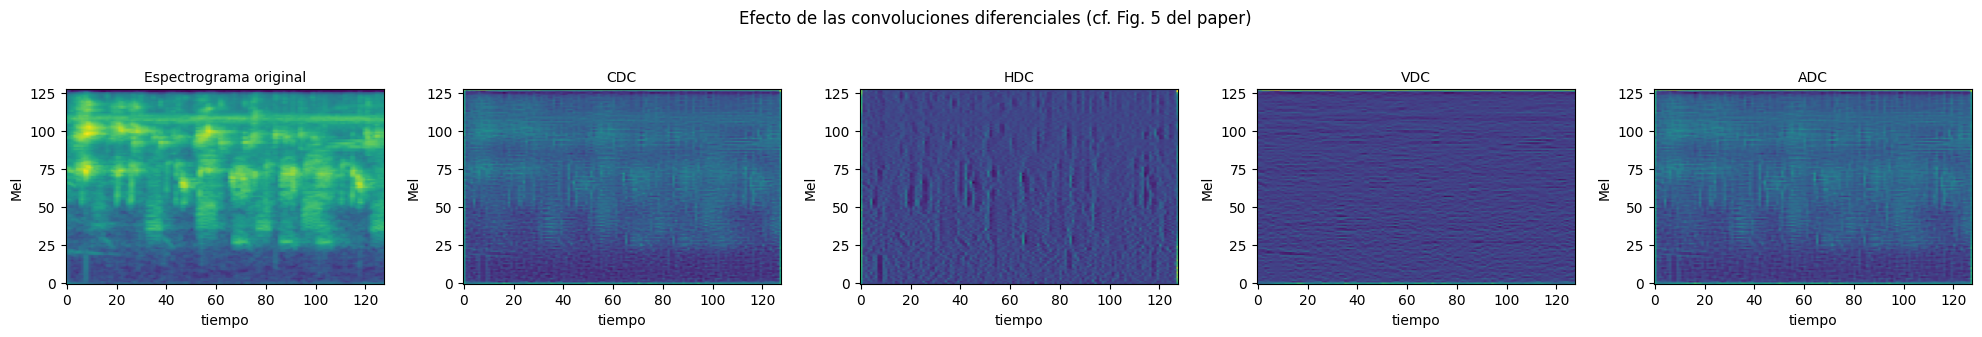

In [12]:
i0 = int(np.argmax(n_por_clip))     # clip con más especies
mel0 = torch.tensor(get_mel_cached(TRAIN_DIR / df[FILE_COL].iloc[i0], "train"))[None, None]
outs = {"Espectrograma original": mel0[0, 0].numpy()}
with torch.no_grad():
    for kind in ["cdc", "hdc", "vdc", "adc"]:
        dc = DiffConv2d(1, 1, kind, theta=0.8 if kind in ("cdc", "adc") else 1.0)
        nn.init.constant_(dc.conv.weight, 1/9)
        outs[kind.upper()] = dc(mel0)[0, 0].numpy()
fig, axes = plt.subplots(1, 5, figsize=(20, 3.2))
for ax, (k, v) in zip(axes, outs.items()):
    ax.imshow(v, aspect="auto", origin="lower", cmap="viridis")
    ax.set_title(k, fontsize=10); ax.set_xlabel("tiempo"); ax.set_ylabel("Mel")
plt.suptitle("Efecto de las convoluciones diferenciales (cf. Fig. 5 del paper)", y=1.04)
plt.tight_layout(); plt.show()

---
## 7. Split por grabación (80/20, semilla 42), normalización y `Dataset`

- **Split por grabación** con `GroupShuffleSplit`: el 20 % de las *grabaciones* va a validación; ninguna grabación aparece en los dos lados (se verifica con `assert`).
- El 20 % de validación se divide, otra vez por grabación, en **`val_es`** (early stopping y selección de checkpoint) y **`val_thr`** (ajuste de umbrales). Las métricas finales del modelo con umbral ajustado se reportan en `val_es`, que no participó en la elección de umbrales. Para la ablación (umbral fijo 0.5 y mAP, que no depende del umbral) usamos toda la validación `val = val_es ∪ val_thr`.
- **Normalización global**: media y desviación de los log-Mel calculadas solo sobre clips de **train** (muestra de hasta 5 000 clips).
- Augmentación ligera solo en entrenamiento (enmascaramiento tiempo/frecuencia estilo SpecAugment, implementado a mano).

In [13]:
def group_split(frame, groups, test_size, seed):
    gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=seed)
    a, b = next(gss.split(frame, groups=groups))
    return a, b

tr_idx, val_idx = group_split(df, df["rec_id"], 0.20, SEED)
val_es_rel, val_thr_rel = group_split(df.iloc[val_idx], df["rec_id"].iloc[val_idx], 0.50, SEED)
val_es_idx, val_thr_idx = val_idx[val_es_rel], val_idx[val_thr_rel]

g = df["rec_id"]
assert set(g.iloc[tr_idx]).isdisjoint(g.iloc[val_idx]), "¡una grabación aparece en train y val!"
assert set(g.iloc[val_es_idx]).isdisjoint(g.iloc[val_thr_idx])
print(f"train  : {len(tr_idx):6d} clips ({100*len(tr_idx)/len(df):.1f}%) | {g.iloc[tr_idx].nunique()} grabaciones")
print(f"val_es : {len(val_es_idx):6d} clips ({100*len(val_es_idx)/len(df):.1f}%) | {g.iloc[val_es_idx].nunique()} grabaciones")
print(f"val_thr: {len(val_thr_idx):6d} clips ({100*len(val_thr_idx)/len(df):.1f}%) | {g.iloc[val_thr_idx].nunique()} grabaciones")

y_tr, y_val_es, y_val_thr = labels_mat[tr_idx], labels_mat[val_es_idx], labels_mat[val_thr_idx]
y_val = np.vstack([y_val_es, y_val_thr])
def _files(idx): return [TRAIN_DIR / f for f in df[FILE_COL].iloc[idx]]
tr_files, val_es_files, val_thr_files = _files(tr_idx), _files(val_es_idx), _files(val_thr_idx)
val_files = val_es_files + val_thr_files

sin_pos_train = [CLASS_NAMES[j] for j in range(N_CLASSES) if y_tr[:, j].sum() == 0]
sin_pos_val   = [CLASS_NAMES[j] for j in range(N_CLASSES) if y_val[:, j].sum() == 0]
print(f"\nClases sin positivos en train: {sin_pos_train or 'ninguna'}")
print(f"Clases sin positivos en val  : {sin_pos_val or 'ninguna'}  (se excluyen de todas las métricas)")
print(f"Clases con >= {MIN_POS_CLASE} positivos en val_thr: {int((y_val_thr.sum(0) >= MIN_POS_CLASE).sum())} de {N_CLASSES}"
      f"  -> solo ellas reciben umbral propio")

# ---- estadísticas globales de normalización (solo train) ----
_sample = np.random.RandomState(SEED).choice(len(tr_files), size=min(5000, len(tr_files)), replace=False)
_stack = np.stack([get_mel_cached(tr_files[i], "train") for i in _sample])
MEL_MEAN, MEL_STD = float(_stack.mean()), float(_stack.std() + 1e-6)
del _stack
print(f"\nNormalización '{NORM}': media={MEL_MEAN:.2f} dB, sigma={MEL_STD:.2f} dB (calculadas sobre {len(_sample)} clips de train)")

def normalize(m):
    if NORM == "minmax":
        return (m - m.min()) / (m.max() - m.min() + 1e-8)
    return (m - MEL_MEAN) / MEL_STD


class BirdClips(Dataset):
    def __init__(self, files, labels=None, split="train", augment=False):
        self.files, self.labels, self.split, self.augment = files, labels, split, augment
    def __len__(self):
        return len(self.files)
    def _spec_augment(self, m):
        m = m.copy(); fill = m.min()
        for _ in range(2):                                   # 2 máscaras de frecuencia
            f0 = np.random.randint(0, N_MELS - 12); m[f0:f0 + np.random.randint(4, 12), :] = fill
        for _ in range(2):                                   # 2 máscaras de tiempo
            t0 = np.random.randint(0, N_FRAMES - 16); m[:, t0:t0 + np.random.randint(4, 16)] = fill
        return m
    def __getitem__(self, i):
        m = get_mel_cached(self.files[i], self.split)
        if self.augment:
            m = self._spec_augment(m)
        x = torch.from_numpy(normalize(m).astype(np.float32))[None]   # (1, 128, 128)
        if self.labels is None:
            return x, Path(self.files[i]).name
        return x, torch.from_numpy(self.labels[i])

NUM_WORKERS = 0 if os.name == "nt" else 2
def make_loader(files, labels, split="train", augment=False, shuffle=False):
    return DataLoader(BirdClips(files, labels, split, augment), batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=NUM_WORKERS, pin_memory=(DEVICE.type == "cuda"))
dl_tr      = make_loader(tr_files, y_tr, augment=True, shuffle=True)
dl_val_es  = make_loader(val_es_files, y_val_es)
dl_val_thr = make_loader(val_thr_files, y_val_thr)
dl_val     = make_loader(val_files, y_val)

train  :  49776 clips (80.0%) | 859 grabaciones
val_es :   6174 clips (9.9%) | 107 grabaciones
val_thr:   6241 clips (10.0%) | 108 grabaciones

Clases sin positivos en train: ['SCIFUS', 'SCINAS']
Clases sin positivos en val  : ['SCIFUS', 'AMEPIC', 'RHISCI', 'SCINAS', 'RHIORN', 'LEPFLA', 'SCIALT']  (se excluyen de todas las métricas)
Clases con >= 10 positivos en val_thr: 30 de 42  -> solo ellas reciben umbral propio

Normalización 'global': media=-20.99 dB, sigma=15.40 dB (calculadas sobre 5000 clips de train)


---
## 8. Entrenamiento y métricas multi-label

Como en el paper: **Adam, lr = 1e-4, batch = 32**. Pérdida **BCEWithLogitsLoss** (adaptación #2). Early stopping sobre el mAP de `val_es`; `ReduceLROnPlateau`; AMP si hay GPU (4 GB de VRAM).

**Métricas** (adaptación #3), todas restringidas a las clases con ≥1 positivo en el conjunto evaluado (`valid`): sin esa máscara, una clase sin positivos aporta F1 = 0 al promedio macro y lo deprime artificialmente, mientras que su AP ni siquiera está definida. Se reporta `n_clases_eval`.

- **mAP** (AP macro): independiente del umbral; métrica principal para comparar modelos.
- **F1 macro / micro, precision / recall macro**: dependen del umbral; se reportan a 0.5 (ablación) y con umbrales ajustados (8.2).
- **Referencia trivial**: un predictor constante obtiene AP = prevalencia de la clase, así que su mAP es la prevalencia media; sirve para dimensionar los resultados.

In [14]:
def compute_metrics(y_true, y_prob, thr=0.5):
    """thr puede ser escalar o vector (N_CLASSES,) de umbrales por clase."""
    thr = np.broadcast_to(np.asarray(thr, dtype=np.float32), (y_true.shape[1],))
    y_pred = (y_prob >= thr[None, :]).astype(int)
    valid = y_true.sum(axis=0) > 0
    yt, yp, ypr = y_true[:, valid], y_pred[:, valid], y_prob[:, valid]
    return {
        "mAP":       average_precision_score(yt, ypr, average="macro"),
        "F1_macro":  f1_score(yt, yp, average="macro", zero_division=0),
        "F1_micro":  f1_score(yt, yp, average="micro", zero_division=0),
        "precision": precision_score(yt, yp, average="macro", zero_division=0),
        "recall":    recall_score(yt, yp, average="macro", zero_division=0),
        "hamming":   hamming_loss(yt, yp),
        "n_clases_eval": int(valid.sum()),
    }

def trivial_map(y_true):
    prev = y_true.mean(axis=0); return float(prev[prev > 0].mean())

@torch.no_grad()
def predict(model, loader):
    model.eval(); probs, trues, loss_sum = [], [], 0.0
    for x, y in loader:
        logits = model(x.to(DEVICE, non_blocking=True)).float()
        loss_sum += F.binary_cross_entropy_with_logits(logits, y.to(DEVICE), reduction="sum").item()
        probs.append(torch.sigmoid(logits).cpu().numpy()); trues.append(y.numpy())
    y_prob, y_true = np.vstack(probs), np.vstack(trues)
    return y_prob, y_true, loss_sum / y_true.size      # BCE media por elemento

def evaluate(model, loader, thr=0.5):
    y_prob, y_true, loss = predict(model, loader)
    m = compute_metrics(y_true, y_prob, thr); m["loss"] = loss
    return m, y_prob, y_true

def train_model(model, name, epochs=EPOCHS, lr=LR, pos_weight=None, dl_train=None, dl_es=None, seed=SEED):
    """Entrena con early stopping sobre mAP(val_es). Devuelve (modelo con mejor checkpoint, historial)."""
    dl_train, dl_es = dl_train or dl_tr, dl_es or dl_val_es
    set_seed(seed)
    model = model.to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=lr)                       # Adam lr=1e-4 (paper)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="max", factor=0.5, patience=4)
    scaler = torch.amp.GradScaler(enabled=(DEVICE.type == "cuda"))
    crit = nn.BCEWithLogitsLoss(pos_weight=None if pos_weight is None else pos_weight.to(DEVICE))
    hist, best_map, best_ep, wait = [], -1, -1, 0
    ckpt = CKPT_DIR / f"{name}.pt"; t_start = time.time()
    for ep in range(1, epochs + 1):
        model.train(); tr_loss, t0 = 0.0, time.time()
        for x, y in dl_train:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad(set_to_none=True)
            with torch.amp.autocast(DEVICE.type, enabled=(DEVICE.type == "cuda")):
                loss = crit(model(x), y)
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
            tr_loss += loss.item() * len(x)
        tr_loss /= len(dl_train.dataset)
        vm, _, _ = evaluate(model, dl_es)
        sched.step(vm["mAP"])
        hist.append({"epoch": ep, "train_loss": tr_loss, "lr": opt.param_groups[0]["lr"],
                     **{f"val_{k}": v for k, v in vm.items()}})
        star = ""
        if vm["mAP"] > best_map:
            best_map, best_ep, wait = vm["mAP"], ep, 0
            torch.save(model.state_dict(), ckpt); star = " *"
        else:
            wait += 1
        print(f"[{name}] ep {ep:3d}/{epochs} | loss {tr_loss:.4f} | val_loss {vm['loss']:.4f} | "
              f"mAP {vm['mAP']:.4f} | F1M {vm['F1_macro']:.4f} | F1m {vm['F1_micro']:.4f} | {time.time()-t0:.0f}s{star}")
        if wait >= PATIENCE:
            print(f"Early stopping (mejor época: {best_ep}, mAP {best_map:.4f})"); break
    TIMES[name] = time.time() - t_start
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    h = pd.DataFrame(hist); h.attrs["best_epoch"] = best_ep
    h.to_csv(OUT_DIR / f"hist_{name}.csv", index=False)
    return model, h

print(f"mAP de un predictor trivial (prevalencia) en val: {trivial_map(y_val):.4f}")

mAP de un predictor trivial (prevalencia) en val: 0.0424


### 8.1 Entrenamiento de las tres variantes con el mismo presupuesto (núcleo de la ablación)

Misma semilla, mismos datos, mismo scheduler, mismas épocas. El modelo final es **MEP-Net completo**; las otras dos variantes se conservan solo como métricas e historial.

In [15]:
results_val, hists, ckpts = {}, {}, {}
for name, tag, kw in VARIANTS:
    print(f"\n{'='*30} {name} ({count_params(MEPNet(**kw))/1e6:.3f}M parámetros) {'='*30}")
    set_seed(); m = MEPNet(n_classes=N_CLASSES, **kw)          # misma inicialización para las 3 variantes
    m, h = train_model(m, tag, epochs=EPOCHS)
    results_val[name], _, _ = evaluate(m, dl_val)            # val completo, umbral 0.5 (mAP no depende)
    hists[name], ckpts[name] = h, CKPT_DIR / f"{tag}.pt"
    if tag == "mepnet_full":
        mepnet, hist_full = m, h
    else:
        del m; torch.cuda.empty_cache()


============================== D-TDNN (base) (2.371M parámetros) ==============================
[dtdnn_base] ep   1/30 | loss 0.2830 | val_loss 0.1368 | mAP 0.2245 | F1M 0.1878 | F1m 0.3880 | 109s *
[dtdnn_base] ep   2/30 | loss 0.0632 | val_loss 0.0640 | mAP 0.4758 | F1M 0.3832 | F1m 0.6697 | 118s *
[dtdnn_base] ep   3/30 | loss 0.0489 | val_loss 0.0618 | mAP 0.5331 | F1M 0.4412 | F1m 0.6901 | 115s *
[dtdnn_base] ep   4/30 | loss 0.0421 | val_loss 0.0555 | mAP 0.5852 | F1M 0.4438 | F1m 0.7126 | 115s *
[dtdnn_base] ep   5/30 | loss 0.0378 | val_loss 0.0585 | mAP 0.5751 | F1M 0.4939 | F1m 0.7246 | 113s
[dtdnn_base] ep   6/30 | loss 0.0348 | val_loss 0.1529 | mAP 0.4496 | F1M 0.4559 | F1m 0.6967 | 115s
[dtdnn_base] ep   7/30 | loss 0.0325 | val_loss 0.0569 | mAP 0.6322 | F1M 0.4732 | F1m 0.7465 | 120s *
[dtdnn_base] ep   8/30 | loss 0.0305 | val_loss 0.0548 | mAP 0.6202 | F1M 0.5248 | F1m 0.7584 | 122s
[dtdnn_base] ep   9/30 | loss 0.0291 | val_loss 0.0534 | mAP 0.6458 | F1M 0.5248 | F1

MEP-Net completo, umbral 0.5:
                val_es  val_thr
mAP             0.7481   0.7627
F1_macro        0.6639   0.6713
F1_micro        0.8132   0.8279
precision       0.7852   0.8299
recall          0.6235   0.6053
hamming         0.0175   0.0150
n_clases_eval  31.0000  31.0000
loss            0.0547   0.0471


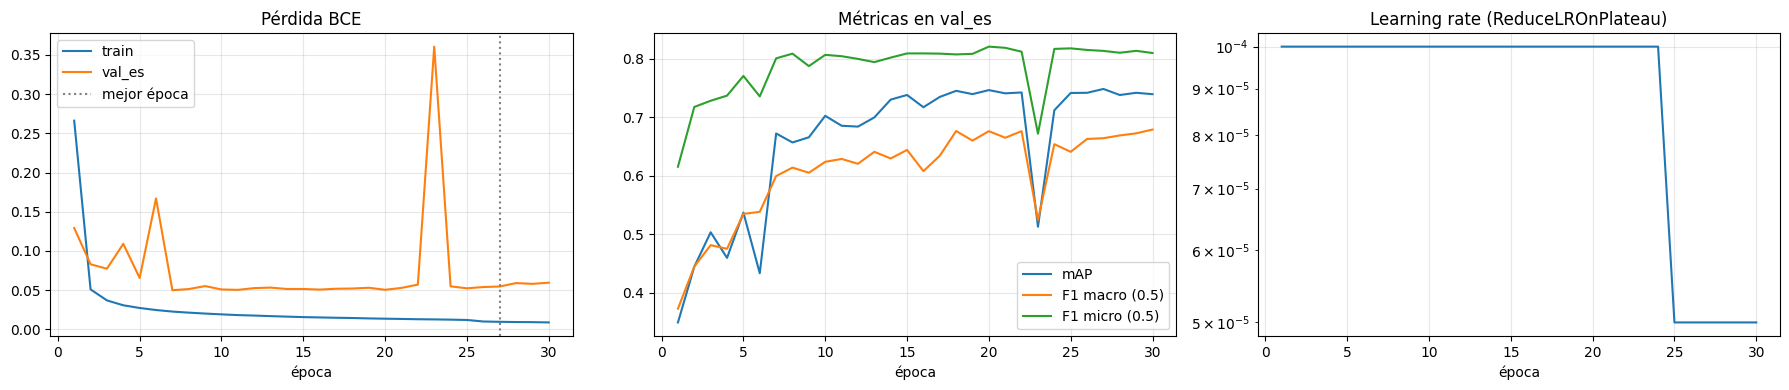

Brecha val-train de la pérdida en la última época: 0.0507 (apreciable; ver curva). Mejor época: 27


In [16]:
metrics_es, prob_es, y_es_true = evaluate(mepnet, dl_val_es)
metrics_thr, prob_thr, y_thr_true = evaluate(mepnet, dl_val_thr)
print("MEP-Net completo, umbral 0.5:")
print(pd.DataFrame({"val_es": metrics_es, "val_thr": metrics_thr}).round(4))

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].plot(hist_full["epoch"], hist_full["train_loss"], label="train")
axes[0].plot(hist_full["epoch"], hist_full["val_loss"], label="val_es")
axes[0].axvline(hist_full.attrs["best_epoch"], color="gray", ls=":", label="mejor época")
axes[0].set_title("Pérdida BCE"); axes[0].set_xlabel("época"); axes[0].legend(); axes[0].grid(alpha=.3)
axes[1].plot(hist_full["epoch"], hist_full["val_mAP"], label="mAP")
axes[1].plot(hist_full["epoch"], hist_full["val_F1_macro"], label="F1 macro (0.5)")
axes[1].plot(hist_full["epoch"], hist_full["val_F1_micro"], label="F1 micro (0.5)")
axes[1].set_title("Métricas en val_es"); axes[1].set_xlabel("época"); axes[1].legend(); axes[1].grid(alpha=.3)
axes[2].plot(hist_full["epoch"], hist_full["lr"]); axes[2].set_yscale("log")
axes[2].set_title("Learning rate (ReduceLROnPlateau)"); axes[2].set_xlabel("época"); axes[2].grid(alpha=.3)
plt.tight_layout(); plt.show()
gap = hist_full["val_loss"].iloc[-1] - hist_full["train_loss"].iloc[-1]
print(f"Brecha val-train de la pérdida en la última época: {gap:.4f} "
      f"({'moderada' if gap < 0.01 else 'apreciable'}; ver curva). Mejor época: {hist_full.attrs['best_epoch']}")

### 8.2 Ajuste del umbral de decisión (en `val_thr`, evaluado en `val_es`)

Tres esquemas de decisión, del más simple al más flexible:
1. **0.5 fijo** (referencia).
2. **Umbral global** que maximiza el F1 macro en `val_thr`.
3. **Umbral por clase**: para cada clase con ≥`MIN_POS_CLASE` positivos en `val_thr`, el umbral que maximiza su F1; las demás usan el global. Responde directamente al sesgo hacia la clase dominante que vimos en v04 (todas las confusiones iban hacia SPHSUR).

Los umbrales se **ajustan en `val_thr`** y se **evalúan en `val_es`**, así que el número reportado no está inflado por haber optimizado sobre el mismo conjunto.

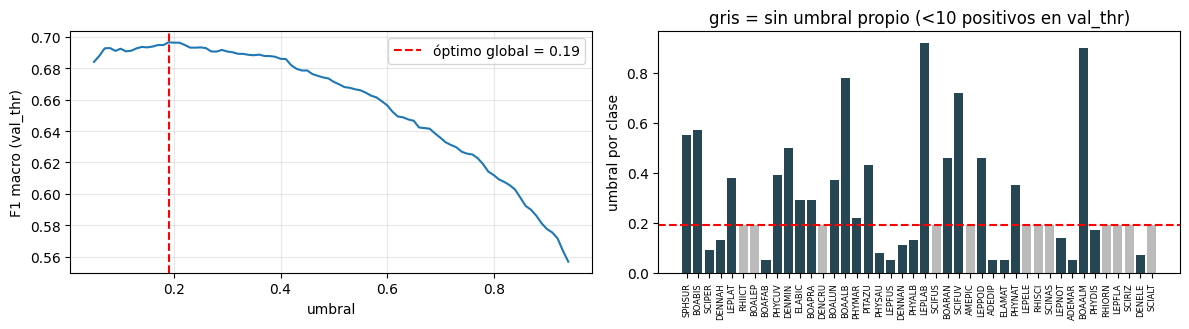

,mAP,F1_macro,F1_micro,precision,recall,hamming,n_clases_eval
"esquema de decisión (ajustado en val_thr, evaluado en val_es)",,,,,,,
0.5 fijo,0.7481,0.6639,0.8132,0.7852,0.6235,0.0175,31.0
global (0.19),0.7481,0.6869,0.8110,0.6971,0.7030,0.0190,31.0
por clase,0.7481,0.6697,0.8047,0.7002,0.6893,0.0190,31.0


Esquema elegido para el test: global (0.19)


In [17]:
def fit_global_threshold(y_true, y_prob, grid=TH_GRID):
    f1s = [compute_metrics(y_true, y_prob, t)["F1_macro"] for t in grid]
    return float(grid[int(np.argmax(f1s))]), np.array(f1s)

def fit_class_thresholds(y_true, y_prob, default, grid=TH_GRID, min_pos=MIN_POS_CLASE):
    th = np.full(y_true.shape[1], default, dtype=np.float32); fitted = np.zeros(y_true.shape[1], bool)
    for j in range(y_true.shape[1]):
        if y_true[:, j].sum() >= min_pos:
            f1s = [f1_score(y_true[:, j], (y_prob[:, j] >= t).astype(int), zero_division=0) for t in grid]
            th[j] = grid[int(np.argmax(f1s))]; fitted[j] = True
    return th, fitted

TH_GLOBAL, f1_curve = fit_global_threshold(y_thr_true, prob_thr)
TH_CLASS, th_fitted = fit_class_thresholds(y_thr_true, prob_thr, default=TH_GLOBAL)

plt.figure(figsize=(12, 3.4))
plt.subplot(1, 2, 1); plt.plot(TH_GRID, f1_curve, "-", lw=1.5)
plt.axvline(TH_GLOBAL, color="r", ls="--", label=f"óptimo global = {TH_GLOBAL:.2f}")
plt.xlabel("umbral"); plt.ylabel("F1 macro (val_thr)"); plt.legend(); plt.grid(alpha=.3)
plt.subplot(1, 2, 2); plt.bar(range(N_CLASSES), TH_CLASS, color=np.where(th_fitted, "#264653", "#bbbbbb"))
plt.axhline(TH_GLOBAL, color="r", ls="--"); plt.xticks(range(N_CLASSES), CLASS_NAMES, rotation=90, fontsize=6)
plt.ylabel("umbral por clase"); plt.title(f"gris = sin umbral propio (<{MIN_POS_CLASE} positivos en val_thr)")
plt.tight_layout(); plt.show()

esquemas = {"0.5 fijo": 0.5, f"global ({TH_GLOBAL:.2f})": TH_GLOBAL, "por clase": TH_CLASS}
tabla_thr = pd.DataFrame({k: compute_metrics(y_es_true, prob_es, v) for k, v in esquemas.items()}).T
tabla_thr.index.name = "esquema de decisión (ajustado en val_thr, evaluado en val_es)"
display(tabla_thr.round(4))
mejor_esquema = tabla_thr["F1_macro"].idxmax()
FINAL_TH = esquemas[mejor_esquema]
print(f"Esquema elegido para el test: {mejor_esquema}")

---
## 9. Ablación (cf. Tabla 4 del paper)

### 9.1 Contribución de MDEConv y BPAM, a igual presupuesto

Las tres variantes se entrenaron en 8.1 con la misma semilla, los mismos datos, el mismo scheduler y las mismas épocas. Reportamos (a) el mejor checkpoint de cada variante sobre `val` (umbral 0.5; el mAP no depende del umbral) y (b) las curvas de mAP por época. La diferencia entre variantes debe leerse junto con la variabilidad entre semillas de 9.2; con una sola semilla, diferencias de ~0.005 de mAP no son concluyentes.

,mAP,F1_macro,F1_micro,precision,recall,hamming,n_clases_eval,params_M,mejor_epoca,min_train
"Modelo (val completo, umbral 0.5)",,,,,,,,,,
D-TDNN (base),0.6159,0.5594,0.7885,0.6814,0.5036,0.0169,35.0,2.3706,22,72.6009
D-TDNN + MDEConv,0.6908,0.6102,0.8024,0.7261,0.5809,0.0165,35.0,2.4446,10,75.1015
MEP-Net (completo),0.7078,0.6438,0.8198,0.7938,0.5788,0.0145,35.0,2.4828,27,177.8414


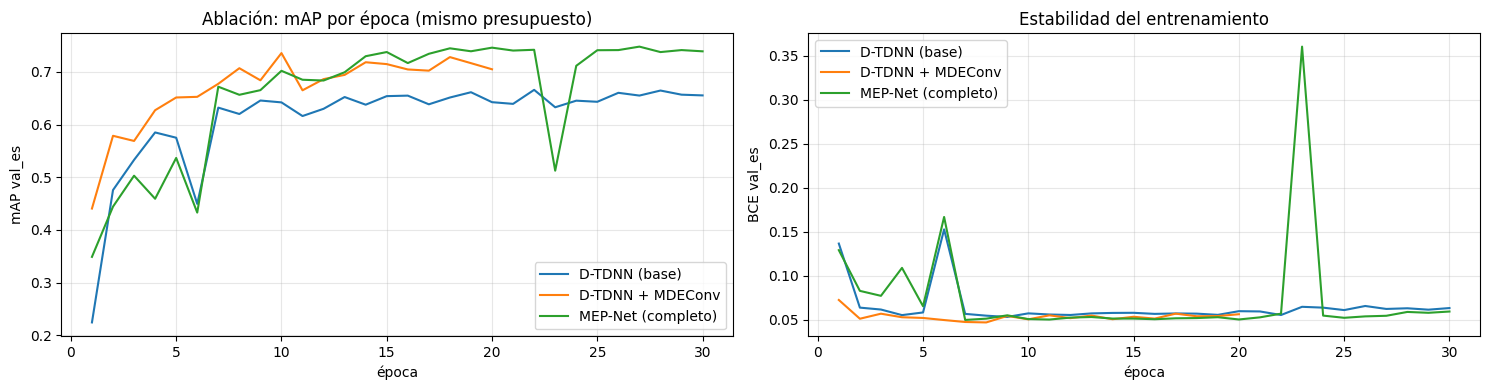

Lectura automática:
  MDEConv sobre el baseline : +0.0749 mAP  -> aporta
  BPAM sobre D-TDNN+MDEConv : +0.0170 mAP  -> aporta
  MEP-Net completo vs base  : +0.0919 mAP
  Mayor salto de val_loss entre épocas consecutivas: {'D-TDNN (base)': 0.096, 'D-TDNN + MDEConv': 0.0213, 'MEP-Net (completo)': 0.3057}


In [18]:
tabla = pd.DataFrame(results_val).T[["mAP", "F1_macro", "F1_micro", "precision", "recall", "hamming", "n_clases_eval"]]
tabla["params_M"] = [count_params(MEPNet(**kw)) / 1e6 for _, _, kw in VARIANTS]
tabla["mejor_epoca"] = [hists[n].attrs["best_epoch"] for n in tabla.index]
tabla["min_train"] = [TIMES.get(t, np.nan) / 60 for _, t, _ in VARIANTS]
tabla.index.name = "Modelo (val completo, umbral 0.5)"
display(tabla.round(4))
tabla.to_csv(OUT_DIR / "ablacion_principal.csv")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
for name, h in hists.items():
    axes[0].plot(h["epoch"], h["val_mAP"], label=name)
    axes[1].plot(h["epoch"], h["val_loss"], label=name)
axes[0].set_ylabel("mAP val_es"); axes[1].set_ylabel("BCE val_es")
for ax in axes: ax.set_xlabel("época"); ax.legend(); ax.grid(alpha=.3)
axes[0].set_title("Ablación: mAP por época (mismo presupuesto)"); axes[1].set_title("Estabilidad del entrenamiento")
plt.tight_layout(); plt.show()

base, mde, full = [results_val[n]["mAP"] for n, _, _ in VARIANTS]
print("Lectura automática:")
print(f"  MDEConv sobre el baseline : {mde-base:+.4f} mAP  -> {'aporta' if mde > base + 0.005 else 'no aporta de forma concluyente' if abs(mde-base) <= 0.005 else 'empeora'}")
print(f"  BPAM sobre D-TDNN+MDEConv : {full-mde:+.4f} mAP  -> {'aporta' if full > mde + 0.005 else 'no aporta de forma concluyente' if abs(full-mde) <= 0.005 else 'empeora'}")
print(f"  MEP-Net completo vs base  : {full-base:+.4f} mAP")
inest = {n: float(h["val_loss"].diff().abs().max()) for n, h in hists.items()}
print(f"  Mayor salto de val_loss entre épocas consecutivas: { {k: round(v,4) for k,v in inest.items()} }")

### 9.2 Variabilidad entre semillas (opcional, `RUN_EXTRA_SEEDS=1`)

Sin esto, la ablación tiene n = 1. Con dos semillas más para MEP-Net completo obtenemos una desviación estándar que dice si las diferencias de 9.1 son reales.

In [19]:
seed_rows = [{"semilla": SEED, **results_val["MEP-Net (completo)"]}]
if RUN_EXTRA_SEEDS:
    for s in SEEDS_EXTRA:
        set_seed(s); m = MEPNet(n_classes=N_CLASSES, use_mdeconv=True, use_bpam=True)
        m, h = train_model(m, f"mepnet_full_seed{s}", epochs=EPOCHS, seed=s)
        r, _, _ = evaluate(m, dl_val); seed_rows.append({"semilla": s, **r}); hists[f"MEP-Net seed {s}"] = h
        del m; torch.cuda.empty_cache()
    seeds_df = pd.DataFrame(seed_rows).set_index("semilla")
    display(seeds_df.round(4))
    print("media ± σ:"); display(pd.DataFrame({"media": seeds_df.mean(), "sigma": seeds_df.std()}).T.round(4))
    seeds_df.to_csv(OUT_DIR / "semillas.csv")
else:
    print("Omitido (RUN_EXTRA_SEEDS=0). Limitación declarada en la Sección 12: la ablación se basa en una semilla.")

Omitido (RUN_EXTRA_SEEDS=0). Limitación declarada en la Sección 12: la ablación se basa en una semilla.


### 9.3 Ablación de θ en las convoluciones diferenciales (réplica de la Fig. 9; opcional, `RUN_THETA_ABLATION=1`)

θ = 0 convierte CDC/ADC en convoluciones ordinarias (solo intensidad); θ = 1 usa solo gradientes. El paper reporta el óptimo en 0.8. Entrenamos D-TDNN+MDEConv (sin BPAM, para aislar el efecto) con θ ∈ {0, 0.5, 0.8, 1.0} a `EXTRA_EPOCHS` épocas.

In [20]:
theta_rows = []
if RUN_THETA_ABLATION:
    for th in [0.0, 0.5, 0.8, 1.0]:
        set_seed(); m = MEPNet(n_classes=N_CLASSES, use_mdeconv=True, use_bpam=False, theta=th)
        m, h = train_model(m, f"theta_{th}", epochs=EXTRA_EPOCHS)
        r, _, _ = evaluate(m, dl_val); theta_rows.append({"theta": th, **r, "mejor_epoca": h.attrs["best_epoch"]})
        del m; torch.cuda.empty_cache()
    theta_df = pd.DataFrame(theta_rows).set_index("theta"); display(theta_df.round(4))
    theta_df.to_csv(OUT_DIR / "ablacion_theta.csv")
    plt.figure(figsize=(6, 3.2)); plt.plot(theta_df.index, theta_df["mAP"], "o-"); plt.xlabel("θ (CDC, ADC)")
    plt.ylabel(f"mAP val ({EXTRA_EPOCHS} épocas)"); plt.title("Réplica de la Fig. 9"); plt.grid(alpha=.3); plt.show()
    print(f"θ óptimo en nuestro dataset: {theta_df['mAP'].idxmax()} (paper: 0.8)")
else:
    print("Omitido (RUN_THETA_ABLATION=0).")

Omitido (RUN_THETA_ABLATION=0).


### 9.4 Ablación del cuello de botella 2D→1D (opcional, `RUN_FREQ_ABLATION=1`)

La interfaz entre BPAM (2D) y D-TDNN (1D) es nuestra decisión de diseño más agresiva: 128 bandas → `FREQ_BINS` bandas por pooling promedio. Medimos 4 (por defecto) vs 8 vs 16 bandas a `EXTRA_EPOCHS` épocas. Más bandas = más información de frecuencia pero `feat_dim` y memoria crecen linealmente.

In [21]:
freq_rows = []
if RUN_FREQ_ABLATION:
    for fb in [4, 8, 16]:
        set_seed(); m = MEPNet(n_classes=N_CLASSES, use_mdeconv=True, use_bpam=True, freq_bins_out=fb)
        m, h = train_model(m, f"freqbins_{fb}", epochs=EXTRA_EPOCHS)
        r, _, _ = evaluate(m, dl_val); freq_rows.append({"bandas": fb, "params_M": count_params(m)/1e6, **r})
        del m; torch.cuda.empty_cache()
    freq_df = pd.DataFrame(freq_rows).set_index("bandas"); display(freq_df.round(4)); freq_df.to_csv(OUT_DIR / "ablacion_bandas.csv")
else:
    print("Omitido (RUN_FREQ_ABLATION=0).")

Omitido (RUN_FREQ_ABLATION=0).


### 9.5 Desbalance de clases en la pérdida (opcional, `RUN_POSWEIGHT_ABLATION=1`)

`BCEWithLogitsLoss(pos_weight = min(neg/pos, 20))` por clase, calculado en train. Es la alternativa "en la pérdida" al umbral por clase de 8.2 ("en la decisión"). Se compara con MEP-Net completo a las mismas `EXTRA_EPOCHS` épocas (se reentrena la referencia para que la comparación sea justa).

In [22]:
if RUN_POSWEIGHT_ABLATION:
    pos = y_tr.sum(0); pw = torch.tensor(np.clip((len(y_tr) - pos) / np.maximum(pos, 1), 1, 20), dtype=torch.float32)
    rows = {}
    for tag, kwargs in [("sin_pos_weight", {}), ("con_pos_weight", {"pos_weight": pw})]:
        set_seed(); m = MEPNet(n_classes=N_CLASSES, use_mdeconv=True, use_bpam=True)
        m, h = train_model(m, f"pw_{tag}", epochs=EXTRA_EPOCHS, **kwargs)
        rows[tag], _, _ = evaluate(m, dl_val); del m; torch.cuda.empty_cache()
    pw_df = pd.DataFrame(rows).T; display(pw_df.round(4)); pw_df.to_csv(OUT_DIR / "ablacion_pos_weight.csv")
else:
    print("Omitido (RUN_POSWEIGHT_ABLATION=0).")

Omitido (RUN_POSWEIGHT_ABLATION=0).


---
## 10. Análisis de resultados y errores (MEP-Net completo, umbrales finales, sobre `val_es`)

Cada bloque termina con una lectura automática de sus números; la interpretación redactada está en la celda de texto que sigue a cada figura y en la Sección 12.

### 10.1 Desempeño por especie
Los rankings de "mejores" y "peores" especies se restringen a clases con ≥`MIN_POS_CLASE` positivos: con 1–5 positivos, un AP de 1.0 (o de 0.0) no es evidencia de nada.

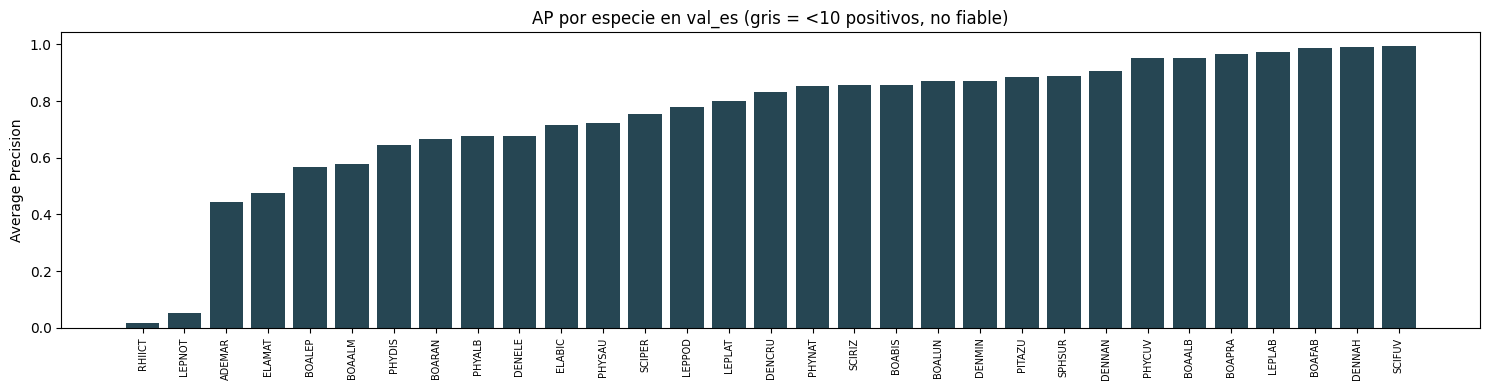

Clases evaluadas: 31 | con >= 10 positivos en val_es: 31

5 especies más difíciles (fiables):


,clase,positivos_train,positivos_val_es,AP,F1,FP,FN,umbral,fiable
5,RHIICT,282,28,0.015,0.000,0,28,0.19,True
33,LEPNOT,812,116,0.051,0.000,1,116,0.19,True
34,ADEMAR,408,58,0.444,0.435,14,38,0.19,True
28,ELAMAT,307,29,0.474,0.444,13,17,0.19,True
6,BOALEP,662,184,0.567,0.545,56,94,0.19,True


5 especies mejor reconocidas (fiables):


,clase,positivos_train,positivos_val_es,AP,F1,FP,FN,umbral,fiable
11,BOAPRA,361,51,0.966,0.741,34,1,0.19,True
21,LEPLAB,1145,69,0.973,0.915,8,4,0.19,True
7,BOAFAB,4748,782,0.987,0.959,26,38,0.19,True
3,DENNAH,389,49,0.990,0.980,1,1,0.19,True
24,SCIFUV,2187,232,0.993,0.985,1,6,0.19,True



Correlación log(positivos en train) vs AP (clases fiables): r = 0.34 -> las clases raras SÍ son peores


In [23]:
y_pred_es = (prob_es >= np.broadcast_to(np.asarray(FINAL_TH, dtype=np.float32), (N_CLASSES,))[None, :]).astype(int)
per_class = pd.DataFrame({
    "clase": CLASS_NAMES,
    "positivos_train": y_tr.sum(0).astype(int),
    "positivos_val_es": y_es_true.sum(0).astype(int),
    "AP": [average_precision_score(y_es_true[:, j], prob_es[:, j]) if y_es_true[:, j].sum() > 0 else np.nan for j in range(N_CLASSES)],
    "F1": f1_score(y_es_true, y_pred_es, average=None, zero_division=0),
    "FP": ((y_pred_es == 1) & (y_es_true == 0)).sum(0),
    "FN": ((y_pred_es == 0) & (y_es_true == 1)).sum(0),
    "umbral": np.broadcast_to(np.asarray(FINAL_TH, dtype=np.float32), (N_CLASSES,)),
})
per_class["fiable"] = per_class["positivos_val_es"] >= MIN_POS_CLASE
per_class.to_csv(OUT_DIR / "metricas_por_clase.csv", index=False)
pc = per_class.dropna(subset=["AP"]).sort_values("AP")

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(pc["clase"], pc["AP"], color=np.where(pc["fiable"], "#264653", "#bbbbbb"))
ax.set_xticklabels(pc["clase"], rotation=90, fontsize=7); ax.set_ylabel("Average Precision")
ax.set_title(f"AP por especie en val_es (gris = <{MIN_POS_CLASE} positivos, no fiable)"); plt.tight_layout(); plt.show()

fiables = pc[pc["fiable"]]
print(f"Clases evaluadas: {len(pc)} | con >= {MIN_POS_CLASE} positivos en val_es: {len(fiables)}")
print("\n5 especies más difíciles (fiables):");  display(fiables.head(5).round(3))
print("5 especies mejor reconocidas (fiables):"); display(fiables.tail(5).round(3))
r_ap = np.corrcoef(np.log1p(fiables["positivos_train"]), fiables["AP"])[0, 1]
print(f"\nCorrelación log(positivos en train) vs AP (clases fiables): r = {r_ap:.2f} "
      f"-> {'las clases raras SÍ son peores' if r_ap > 0.3 else 'la rareza NO explica el error por clase'}")

**Lectura.** «Completar tras la ejecución: nombrar las 3–5 especies con menor AP entre las fiables, su número de ejemplos y qué tienen en común (p. ej. mismo género, cantos de banda ancha, alta co-ocurrencia con la clase dominante). Indicar si la correlación rareza–AP apoya o no la hipótesis "clases raras → peor desempeño"; en v04 la tabla la contradecía.»

### 10.2 Confusiones entre especies y sesgo hacia la clase dominante
Para cada clip contamos qué especie se predijo de más cuando faltó la real (FN → FP en el mismo clip). Además medimos qué fracción de todos los falsos positivos pertenece a la clase dominante: si es mucho mayor que su prevalencia, el modelo está usando el *prior* de esa clase como comodín.

In [24]:
conf = np.zeros((N_CLASSES, N_CLASSES))
for i in range(len(y_es_true)):
    fn = np.where((y_es_true[i] == 1) & (y_pred_es[i] == 0))[0]
    fp = np.where((y_es_true[i] == 0) & (y_pred_es[i] == 1))[0]
    for a in fn:
        for b in fp:
            conf[a, b] += 1
pairs = sorted([(CLASS_NAMES[a], CLASS_NAMES[b], int(conf[a, b])) for a in range(N_CLASSES) for b in range(N_CLASSES) if conf[a, b] > 0],
               key=lambda t: -t[2])[:10]
print("Top confusiones (especie real omitida -> especie predicha en su lugar):")
for a, b, c in pairs: print(f"  {a:10s} -> {b:10s}  ({c} clips)")

fp_total = per_class["FP"].sum(); j_dom = CLASS_NAMES.index(CLASE_DOMINANTE)
share_fp_dom = per_class["FP"].iloc[j_dom] / max(fp_total, 1)
prev_dom = y_tr[:, j_dom].mean()
print(f"\nClase dominante {CLASE_DOMINANTE}: {100*share_fp_dom:.1f}% de todos los FP vs {100*prev_dom:.1f}% de prevalencia en train "
      f"-> {'sesgo de prior claro' if share_fp_dom > 1.5*prev_dom else 'sin sesgo de prior apreciable'} con el esquema '{mejor_esquema}'")
share_conf_dom = sum(c for _, b, c in pairs if b == CLASE_DOMINANTE) / max(sum(c for *_, c in pairs), 1)
print(f"Fracción del top-10 de confusiones que apunta a {CLASE_DOMINANTE}: {100*share_conf_dom:.0f}%")

# Co-ocurrencia real en train: ¿las confusiones siguen a las especies que suelen sonar juntas?
co = (y_tr.T @ y_tr); np.fill_diagonal(co, 0)
top_co = [(CLASS_NAMES[a], CLASS_NAMES[b], int(co[a, b])) for a, b in zip(*np.unravel_index(np.argsort(co.ravel())[::-1][:6], co.shape))]
print("\nPares que más co-ocurren en train:", top_co)

Top confusiones (especie real omitida -> especie predicha en su lugar):
  PHYSAU     -> PHYALB      (58 clips)
  LEPNOT     -> BOAALM      (56 clips)
  BOAALM     -> SPHSUR      (50 clips)
  LEPLAT     -> DENMIN      (49 clips)
  SCIPER     -> BOABIS      (44 clips)
  BOAALM     -> SCIPER      (40 clips)
  BOALEP     -> SPHSUR      (29 clips)
  PITAZU     -> BOALUN      (25 clips)
  BOAALM     -> BOAPRA      (25 clips)
  BOABIS     -> SPHSUR      (24 clips)

Clase dominante SPHSUR: 11.2% de todos los FP vs 21.0% de prevalencia en train -> sin sesgo de prior apreciable con el esquema 'global (0.19)'
Fracción del top-10 de confusiones que apunta a SPHSUR: 26%

Pares que más co-ocurren en train: [('SPHSUR', 'BOABIS', 7269), ('BOABIS', 'SPHSUR', 7269), ('LEPLAT', 'SPHSUR', 3457), ('SPHSUR', 'LEPLAT', 3457), ('LEPLAT', 'BOABIS', 3129), ('BOABIS', 'LEPLAT', 3129)]


**Lectura.** «Completar: ¿la clase dominante concentra los FP muy por encima de su prevalencia? ¿El umbral por clase redujo ese sesgo respecto al umbral 0.5 (comparar con la tabla de 8.2)? ¿Las confusiones coinciden con los pares que más co-ocurren en train (lo que apuntaría a solapamiento acústico real) o no (lo que apuntaría a un problema del modelo)?»

### 10.3 Clips con mayor error y efecto del número de especies

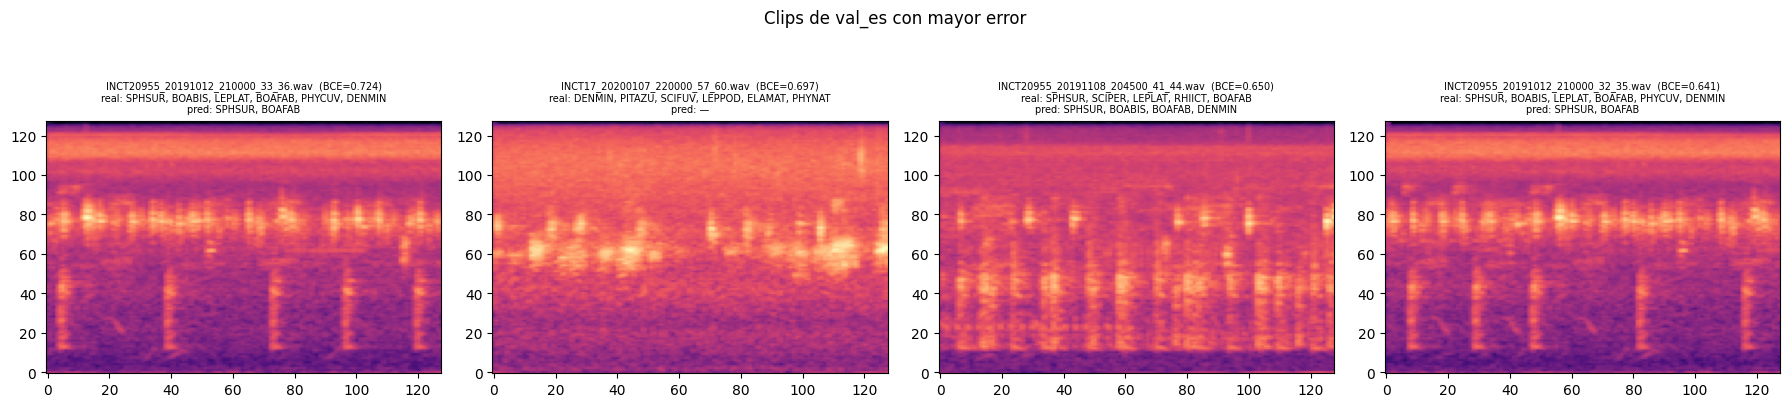

Máxima correlación entre los peores clips: 0.839 (clips distintos)


,clips,BCE_medio,exact_match
especies_en_clip,,,
0,2295,0.0084,0.9102
1,1108,0.0643,0.6218
2,1059,0.0744,0.4655
3,1043,0.0691,0.4343
4,414,0.1001,0.3575
5,175,0.2262,0.0457
6,72,0.1908,0.0833
7,8,0.1549,0.0000


Exact-match global (todas las etiquetas correctas): 62.9% | clips vacíos bien detectados: 91.0%


In [25]:
eps = 1e-7
bce_clip = -(y_es_true * np.log(prob_es + eps) + (1 - y_es_true) * np.log(1 - prob_es + eps)).mean(axis=1)
worst = np.argsort(bce_clip)[::-1][:4]
fig, axes = plt.subplots(1, len(worst), figsize=(4.5*len(worst), 3.8))
mats = []
for ax, i in zip(np.atleast_1d(axes), worst):
    m = get_mel_cached(val_es_files[i], "train"); mats.append(m.ravel())
    ax.imshow(m, aspect="auto", origin="lower", cmap="magma")
    reales = [CLASS_NAMES[j] for j in range(N_CLASSES) if y_es_true[i, j] == 1]
    preds  = [CLASS_NAMES[j] for j in range(N_CLASSES) if y_pred_es[i, j] == 1]
    ax.set_title(f"{Path(val_es_files[i]).name}  (BCE={bce_clip[i]:.3f})\nreal: {', '.join(reales) or '—'}\npred: {', '.join(preds) or '—'}", fontsize=7)
plt.suptitle("Clips de val_es con mayor error", y=1.06); plt.tight_layout(); plt.show()
if len(mats) > 1:
    cc = np.corrcoef(np.stack(mats)); np.fill_diagonal(cc, 0)
    print(f"Máxima correlación entre los peores clips: {cc.max():.3f} "
          f"({'¡casi idénticos: revisar duplicados (4.3)!' if cc.max() > 0.98 else 'clips distintos'})")

n_lab = y_es_true.sum(axis=1)
tab = pd.DataFrame({"especies_en_clip": n_lab.astype(int), "BCE": bce_clip, "aciertos_exactos": (y_pred_es == y_es_true).all(1)})
res_n = tab.groupby("especies_en_clip").agg(clips=("BCE", "size"), BCE_medio=("BCE", "mean"), exact_match=("aciertos_exactos", "mean"))
display(res_n.round(4))
print(f"Exact-match global (todas las etiquetas correctas): {100*tab['aciertos_exactos'].mean():.1f}% | "
      f"clips vacíos bien detectados: {100*tab[tab.especies_en_clip==0]['aciertos_exactos'].mean():.1f}%")

**Lectura.** «Completar: describir los 2–3 peores clips (¿varias especies solapadas? ¿ruido de lluvia/viento? ¿clip vacío con predicción?), confirmar si el BCE crece monótonamente con el número de especies y en cuánto cae el exact-match de 1 a ≥4 especies. Conclusión esperada si se repite el patrón de v04: el error está dominado por el solapamiento acústico, no por la rareza de las clases.»

### 10.4 Comparación honesta: ¿cuánto cambiaron las métricas al eliminar la fuga?

Referencia de v04 (split aleatorio por clip, MEP-Net a 60 épocas, umbral 0.5, sobre su validación): mAP 0.978, F1 macro 0.870, F1 micro 0.962. Esos valores no son comparables con los de esta versión porque medían, en parte, memorización de audio ya visto. Aquí los ponemos lado a lado para que la caída (si la hay) se interprete correctamente: **es la diferencia entre evaluar en fragmentos de grabaciones ya vistas y evaluar en grabaciones nuevas.**

In [26]:
ref_v04 = {"mAP": 0.9778, "F1_macro": 0.8703, "F1_micro": 0.9622, "precision": 0.8972, "recall": 0.8505}
comp = pd.DataFrame({"v04 (split por clip, 60 ep, thr 0.5)": ref_v04,
                     f"v05 (split por grabación, {EPOCHS} ep, thr 0.5)": {k: metrics_es[k] for k in ref_v04},
                     f"v05 (split por grabación, {EPOCHS} ep, {mejor_esquema})": {k: tabla_thr.loc[mejor_esquema, k] for k in ref_v04}})
display(comp.round(4))
d = ref_v04["mAP"] - metrics_es["mAP"]
print(f"Cambio de mAP al eliminar la fuga (y reducir épocas): {-d:+.4f}. "
      f"Parte de la caída se debe a menos épocas (60 -> {EPOCHS}); la comparación limpia entre splits exigiría igualar épocas.")

,"v04 (split por clip, 60 ep, thr 0.5)","v05 (split por grabación, 30 ep, thr 0.5)","v05 (split por grabación, 30 ep, global (0.19))"
mAP,0.9778,0.7481,0.7481
F1_macro,0.8703,0.6639,0.6869
F1_micro,0.9622,0.8132,0.8110
precision,0.8972,0.7852,0.6971
recall,0.8505,0.6235,0.7030


Cambio de mAP al eliminar la fuga (y reducir épocas): -0.2297. Parte de la caída se debe a menos épocas (60 -> 30); la comparación limpia entre splits exigiría igualar épocas.


---
## 11. Predicciones sobre el test set

`predicciones_test.csv`: mismo formato que `train.csv` (nombre + 42 columnas binarias) con el esquema de decisión elegido en 8.2. `predicciones_test_probs.csv`: probabilidades, por si la evaluación usa métricas basadas en ranking. Como chequeo de sanidad comparamos la prevalencia predicha por especie con la prevalencia de train.

31187 predicciones guardadas (esquema: global (0.19))
Especies predichas por clip (media): 1.50 (train: 1.51) | clips sin especie: 37.2% (train: 36.2%)


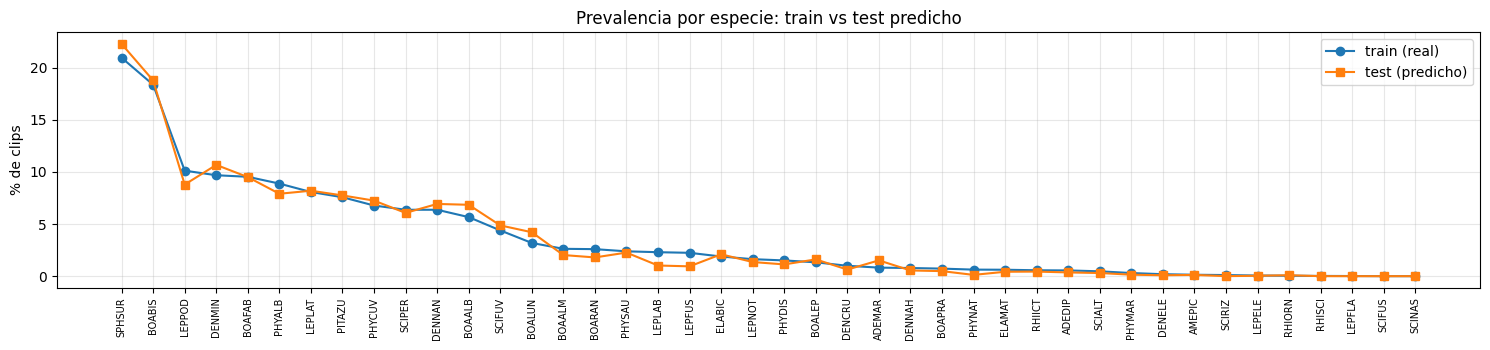

Mayores desvíos (puntos %):


LEPPOD    1.34
SPHSUR    1.32
LEPFUS    1.30
LEPLAB    1.28
BOAALB    1.18
dtype: float64

,filename,SPHSUR,BOABIS,SCIPER,DENNAH,LEPLAT,RHIICT,BOALEP,BOAFAB,PHYCUV,...,SCINAS,LEPNOT,ADEMAR,BOAALM,PHYDIS,RHIORN,LEPFLA,SCIRIZ,DENELE,SCIALT
0,INCT17_20191125_040000_0_3.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,INCT17_20191125_040000_10_13.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,INCT17_20191125_040000_11_14.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,INCT17_20191125_040000_12_15.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,INCT17_20191125_040000_13_16.wav,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [27]:
dl_test = DataLoader(BirdClips(test_files, None, "test"), batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
mepnet.eval(); all_probs, all_names = [], []
with torch.no_grad():
    for x, names in dl_test:
        all_probs.append(torch.sigmoid(mepnet(x.to(DEVICE))).float().cpu().numpy()); all_names += list(names)
probs_test = np.vstack(all_probs)
th_vec = np.broadcast_to(np.asarray(FINAL_TH, dtype=np.float32), (N_CLASSES,))
pred_test = (probs_test >= th_vec[None, :]).astype(int)
sub_bin = pd.DataFrame(pred_test, columns=CLASS_NAMES); sub_bin.insert(0, FILE_COL, all_names)
sub_prob = pd.DataFrame(probs_test.round(5), columns=CLASS_NAMES); sub_prob.insert(0, FILE_COL, all_names)
sub_bin.to_csv("predicciones_test.csv", index=False); sub_prob.to_csv("predicciones_test_probs.csv", index=False)
pd.Series(th_vec, index=CLASS_NAMES, name="umbral").to_csv(OUT_DIR / "umbrales_finales.csv")
print(f"{len(sub_bin)} predicciones guardadas (esquema: {mejor_esquema})")
print(f"Especies predichas por clip (media): {pred_test.sum(1).mean():.2f} (train: {n_por_clip.mean():.2f}) | "
      f"clips sin especie: {100*(pred_test.sum(1)==0).mean():.1f}% (train: {100*(n_por_clip==0).mean():.1f}%)")

prev = pd.DataFrame({"train %": 100*y_tr.mean(0), "test predicho %": 100*pred_test.mean(0)}, index=CLASS_NAMES).sort_values("train %", ascending=False)
plt.figure(figsize=(15, 3.6)); plt.plot(prev.index, prev["train %"], "o-", label="train (real)"); plt.plot(prev.index, prev["test predicho %"], "s-", label="test (predicho)")
plt.xticks(rotation=90, fontsize=7); plt.ylabel("% de clips"); plt.legend(); plt.grid(alpha=.3); plt.title("Prevalencia por especie: train vs test predicho"); plt.tight_layout(); plt.show()
print("Mayores desvíos (puntos %):"); display((prev["test predicho %"] - prev["train %"]).abs().sort_values(ascending=False).head(5).round(2))
sub_bin.head()

---
## 12. Conclusiones, diferencias con el paper y limitaciones

> Los valores entre «» se completan con la salida de la corrida (la celda siguiente imprime un resumen listo para copiar).

**Sobre el método.** MEP-Net combina tres ideas complementarias: (i) el backbone D-TDNN modela la dinámica temporal del canto con conexiones densas y pocos parámetros; (ii) MDEConv inyecta información de **gradiente** tiempo-frecuencia en 4 direcciones, realzando detalles finos que el ruido de fondo tiende a enmascarar; (iii) BPAM pondera **parches** del espectrograma a dos escalas y filtra los irrelevantes por similitud con un embedding de tarea.

**Resultados.** Con split por grabación y umbral «esquema», MEP-Net completo alcanza mAP «x», F1 macro «x» y F1 micro «x» en `val_es`, frente a un mAP trivial de «x». En la ablación a igual presupuesto, MDEConv aporta «±x» mAP sobre el baseline y BPAM «±x» sobre D-TDNN+MDEConv; «indicar si el orden coincide con la Tabla 4 del paper y si la diferencia supera la σ entre semillas (9.2) o es una sola semilla».

**Hallazgo principal del laboratorio: la fuga del split por clip.** Los clips son ventanas solapadas (paso 1 s) de grabaciones largas. Un split aleatorio por clip dejaba «x %» de los clips de validación con audio compartido con entrenamiento; con ese split medíamos mAP 0.978 (v04). Con split por grabación el mAP es «x». La diferencia no es una pérdida de calidad del modelo: es la diferencia entre medir memorización y medir generalización a grabaciones nuevas, que es lo que el test exige («indicar si test comparte grabaciones con train según 4.2»).

**Errores.** «Resumen de 10.1–10.3: especies fiables con peor AP y su rasgo común; si la rareza explica o no el error (r = x); porcentaje de FP que absorbe la clase dominante con umbral 0.5 vs por clase; BCE creciente con el número de especies; peores clips». Se detectaron «x» grupos de clips duplicados exactos («x» cruzan train↔test).

**Diferencias importantes respecto a la propuesta original** (además de las adaptaciones multi-label de la Sección 2):
- Interfaz 2D→1D entre BPAM y D-TDNN definida por nosotros (pooling de frecuencia 128→«4» bandas y aplanado canales×bandas); el paper no la especifica. «Resultado de 9.4 si se ejecutó».
- BN+ReLU entre las convoluciones del stem de MDEConv (flag `STEM_NONLINEAR`); tres convoluciones lineales encadenadas equivalen a una sola.
- Dilataciones 1-2-3 en las capas D-TDNN (no listadas en el paper).
- Menos épocas que el paper (200 → «30») por límite de cómputo (GPU de 4 GB), con early stopping y scheduler; augmentación tiempo/frecuencia ligera que el paper no usa.
- Estandarización global de los log-Mel en lugar de min-max por clip (v04); umbral ajustado en validación (el paper usa argmax).
- Canales del tramo 2D (32) elegidos para caber en 4 GB manteniendo ~2.5M parámetros (paper ≈ 3M).

**Limitaciones.**
- Una sola semilla en la ablación principal («o: σ entre semillas = x, 9.2»); diferencias pequeñas de mAP no son concluyentes.
- «x» clases tienen <10 positivos en validación: su AP no es interpretable y no reciben umbral propio.
- Los umbrales se ajustan en `val_thr` (≈10 % de los datos): para clases medianas el óptimo por clase es ruidoso.
- El checkpoint se elige con `val_es` y las métricas finales también se reportan en `val_es`: queda una ligera optimismo de selección de modelo (no de umbral).
- No se exploró el solapamiento acústico con separación de fuentes ni con pérdidas específicas para co-ocurrencia.

**Trabajo futuro.** Split estratificado por grupo (para garantizar positivos de las clases raras en validación), pérdida focal o `pos_weight` (9.5), mixup de audio para clases raras, y evaluación con varias semillas.

**Reproducibilidad.** Semilla 42 en split, baraje e inicialización; checkpoints en `checkpoints/`; espectrogramas en `mel_cache_v2/`; historiales, tablas y umbrales en `salidas/`; `requirements.txt` adjunto. Tabla de tiempos a continuación.

In [28]:
# ---- Resumen automático para completar la Sección 12 y el video ----
def fmt(d): return {k: round(float(v), 4) for k, v in d.items() if isinstance(v, (int, float, np.floating))}
print("=== RESUMEN DE LA CORRIDA ===")
print(f"Split: train {len(tr_idx)} / val_es {len(val_es_idx)} / val_thr {len(val_thr_idx)} clips | "
      f"fuga del split por clip (v04): {100*leaked/n_val_old:.1f}% | test comparte grabaciones con train: {len(inter)}")
print(f"mAP trivial (val): {trivial_map(y_val):.4f}")
print(f"MEP-Net en val_es, thr 0.5      : {fmt(metrics_es)}")
print(f"MEP-Net en val_es, {mejor_esquema:15s}: {fmt(tabla_thr.loc[mejor_esquema].to_dict())}")
print(f"Ablación (val, thr 0.5): base {base:.4f} | +MDEConv {mde:.4f} ({mde-base:+.4f}) | completo {full:.4f} ({full-mde:+.4f})")
if RUN_EXTRA_SEEDS: print(f"σ entre semillas (mAP): {pd.DataFrame(seed_rows)['mAP'].std():.4f}")
if theta_rows: print(f"θ óptimo: {pd.DataFrame(theta_rows).set_index('theta')['mAP'].idxmax()}")
if freq_rows:  print(f"bandas óptimas: {pd.DataFrame(freq_rows).set_index('bandas')['mAP'].idxmax()}")
print(f"Especies fiables peores: {fiables.head(3)['clase'].tolist()} | r(rareza, AP) = {r_ap:.2f}")
print(f"FP absorbidos por {CLASE_DOMINANTE}: {100*share_fp_dom:.1f}% (prevalencia {100*prev_dom:.1f}%)")
print(f"Duplicados exactos: {len(dup_groups)} grupos, {len(cross_tt)} cruzan train↔test")
print(f"Clases con <{MIN_POS_CLASE} positivos en val_es: {int((~per_class['fiable']).sum())}")

print("\n=== TIEMPOS DE ENTRENAMIENTO ===")
tiempos = pd.DataFrame({"minutos": {k: v/60 for k, v in TIMES.items()}}); tiempos["horas"] = tiempos["minutos"]/60
display(tiempos.round(2)); tiempos.to_csv(OUT_DIR / "tiempos.csv")
print(f"Total: {tiempos['horas'].sum():.2f} h en {torch.cuda.get_device_name(0) if DEVICE.type=='cuda' else 'CPU'}")

=== RESUMEN DE LA CORRIDA ===
Split: train 49776 / val_es 6174 / val_thr 6241 clips | fuga del split por clip (v04): 99.7% | test comparte grabaciones con train: 0
mAP trivial (val): 0.0424
MEP-Net en val_es, thr 0.5      : {'mAP': 0.7481, 'F1_macro': 0.6639, 'F1_micro': 0.8132, 'precision': 0.7852, 'recall': 0.6235, 'hamming': 0.0175, 'n_clases_eval': 31.0, 'loss': 0.0547}
MEP-Net en val_es, global (0.19)  : {'mAP': 0.7481, 'F1_macro': 0.6869, 'F1_micro': 0.811, 'precision': 0.6971, 'recall': 0.703, 'hamming': 0.019, 'n_clases_eval': 31.0}
Ablación (val, thr 0.5): base 0.6159 | +MDEConv 0.6908 (+0.0749) | completo 0.7078 (+0.0170)
Especies fiables peores: ['RHIICT', 'LEPNOT', 'ADEMAR'] | r(rareza, AP) = 0.34
FP absorbidos por SPHSUR: 11.2% (prevalencia 21.0%)
Duplicados exactos: 1 grupos, 1 cruzan train↔test
Clases con <10 positivos en val_es: 11

=== TIEMPOS DE ENTRENAMIENTO ===


,minutos,horas
dtdnn_base,72.60,1.21
dtdnn_mde,75.10,1.25
mepnet_full,177.84,2.96


Total: 5.43 h en NVIDIA RTX A2000 Laptop GPU
